# BB84 QKD vs Diffie-Hellman: Cryptography Comparison
## QIntern 2026 | Project qi26_26 | Week 5

**Quantum Lead:** Shahreen Sultana  
**Classical Lead:** Kanishka  
**Mentor:** Joselyn Lagunas  

This notebook merges the quantum BB84 QKD implementation and the
classical Diffie-Hellman key exchange to produce a direct side-by-side
security and performance comparison.

# Cell 1 — Installations:

In [1]:
# ── Installations ─────────────────────────────────────────
!pip install scipy numpy matplotlib -q

# Cell 2 — Imports:

In [2]:
# ── Imports ───────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
import scipy.stats as stats
from datetime import datetime, timezone
import os
import urllib.request
from scipy import stats

In [3]:
# ── Publication Quality Settings ──────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'figure.figsize': (10, 6)
})
print("Settings applied!")

Settings applied!


## 1. Protocol Overview

**Problem:** Secure key establishment  
**Quantum approach:** BB84 Quantum Key Distribution  
**Classical approach:** Diffie-Hellman Key Exchange (DH)

**Core difference:**
- BB84 provides **information-theoretic security** — secure against
  any computationally unbounded adversary, guaranteed by physics
- Diffie-Hellman provides **computational security** — secure only
  if the discrete logarithm problem remains hard, vulnerable to
  quantum computers via Shor's algorithm

**Agreed protocol (both sides):**
- Qubits transmitted: 1,000 / 2,000 / 4,000 / 8,000
- Expected sifted key: ~500 / 1,000 / 2,000 / 4,000 bits
- Trials: 10 per configuration
- Eavesdropping scenarios: 0%, 25%, 50%, 100% intercept rate
- QBER threshold: 11% (Shor and Preskill 2000)

**References:**
- Bennett and Brassard (1984) — original BB84 protocol
- Shor and Preskill (2000, Physical Review Letters,
  DOI: 10.1103/PhysRevLett.85.441) — security proof, 11% QBER threshold
- Diffie and Hellman (1976, IEEE TIT, DOI: 10.1109/TIT.1976.1055638)
  — original DH paper, computational hardness assumption
- Rath, Panth, Bhaskar (2026, arXiv:2603.27278) — QBER analysis,
  near-linear relationship between eavesdropping and QBER
- Escanez-Exposito et al. (2024, Future Internet,
  DOI: 10.3390/fi16080275) — BB84 simulation under noise and attack

## 2. Setup and Load Results

Loading quantum (BB84) and classical (Diffie-Hellman) experiment logs.

**Logging schema follows:** Measurement Framework Consolidated v1  
(docs/measurement_framework_consolidated.md)

In [4]:
# ── Load BB84 Results from GitHub ────────────────────────
BASE_URL = "https://raw.githubusercontent.com/Shel-y/qintern2026-quantum-benchmarking/main/results/quantum/bb84/json/"

def load_json(url):
    with urllib.request.urlopen(url) as response:
        return json.load(response)

bb84_benchmark = load_json(BASE_URL + "bb84_experiment_001.json")
bb84_layer2    = load_json(BASE_URL + "bb84_experiment_002.json")
bb84_perf      = load_json(BASE_URL + "bb84_experiment_003.json")

print("BB84 results loaded!")
print(f"Experiment 001: {bb84_benchmark['experiment_id']}")
print(f"Experiment 002: {bb84_layer2['experiment_id']}")
print(f"Experiment 003: {bb84_perf['experiment_id']}")

BB84 results loaded!
Experiment 001: qi26_26_BB84_001
Experiment 002: qi26_26_BB84_002
Experiment 003: qi26_26_BB84_003


In [11]:
# ── Load Per-Trial BB84 Results (for distributional plots) ──
bb84_pertrial_raw = load_json(BASE_URL + "bb84_experiment_004.json")
bb84_pertrial = bb84_pertrial_raw['metrics']['per_trial_results']

print(f"Experiment 004: {bb84_pertrial_raw['experiment_id']}")
print(f"Per-trial records loaded: {len(bb84_pertrial)}")

import pandas as pd
pertrial_df = pd.DataFrame(bb84_pertrial)
print(pertrial_df.groupby(['n_qubits', 'eavesdrop_rate'])['qber'].agg(['mean', 'std', 'count']))

Experiment 004: qi26_26_BB84_004
Per-trial records loaded: 160
                            mean       std  count
n_qubits eavesdrop_rate                          
1000     0.00            0.00000  0.000000     10
         0.25            0.06399  0.012950     10
         0.50            0.12821  0.010415     10
         1.00            0.25770  0.021691     10
2000     0.00            0.00000  0.000000     10
         0.25            0.06024  0.009154     10
         0.50            0.12314  0.009146     10
         1.00            0.25058  0.009830     10
4000     0.00            0.00000  0.000000     10
         0.25            0.06114  0.003368     10
         0.50            0.12577  0.007808     10
         1.00            0.25483  0.011551     10
8000     0.00            0.00000  0.000000     10
         0.25            0.06362  0.003769     10
         0.50            0.12429  0.005581     10
         1.00            0.24955  0.006024     10


In [5]:
# ── Load DH Results from GitHub ───────────────────────────
DH_URL = "https://raw.githubusercontent.com/Shel-y/qintern2026-quantum-benchmarking/main/classical_implementations/Diffie_Helman/dh_detailed_results.json"

dh_raw = load_json(DH_URL)  # reuses the load_json() helper already defined in Section 2

import pandas as pd
dh_df = pd.DataFrame(dh_raw)

print(f"DH results loaded: {len(dh_df)} records")
print(f"Key sizes: {sorted(dh_df['key_size'].unique().tolist())}")
print(f"Attack scenarios: {dh_df['attack_scenario'].unique().tolist()}")

KEY_SIZES = sorted(dh_df['key_size'].unique().tolist())
ATTACK_MAP = {'MITM_0': 0.0, 'MITM_25': 0.25, 'MITM_50': 0.5, 'MITM_100': 1.0}
dh_df['attack_rate_norm'] = dh_df['attack_scenario'].map(ATTACK_MAP)

dh_summary = dh_df.groupby(['key_size', 'attack_scenario']).agg(
    mean_runtime=('runtime_seconds', 'mean'),
    std_runtime=('runtime_seconds', 'std'),
    mean_cpu=('cpu_time_seconds', 'mean'),
    mean_ram=('peak_ram_mb', 'mean'),
    mean_kgr=('key_gen_rate', 'mean'),
    success_rate=('success', 'mean'),  # fraction of trials where MITM succeeded
    n_trials=('success', 'count')
).reset_index()

# Sort by key_size then attack_rate_norm so it reads top-to-bottom like your BB84 summary table
dh_summary['attack_rate_norm'] = dh_summary['attack_scenario'].map(ATTACK_MAP)
dh_summary = dh_summary.sort_values(['key_size', 'attack_rate_norm']).reset_index(drop=True)

print("\nDH Summary (mean over 10 trials per configuration):")
print(dh_summary.to_string(index=False))

DH results loaded: 160 records
Key sizes: [1000, 2000, 4000, 8000]
Attack scenarios: ['MITM_0', 'MITM_25', 'MITM_50', 'MITM_100']

DH Summary (mean over 10 trials per configuration):
 key_size attack_scenario  mean_runtime  std_runtime  mean_cpu  mean_ram     mean_kgr  success_rate  n_trials  attack_rate_norm
     1000          MITM_0      0.022925     0.003493  0.021875  0.003628 44512.751744           1.0        10              0.00
     1000         MITM_25      0.022236     0.005246  0.023438  0.003735 47783.911424           0.9        10              0.25
     1000         MITM_50      0.025300     0.005851  0.025000  0.003890 41376.998646           0.6        10              0.50
     1000        MITM_100      0.028646     0.002038  0.026562  0.004154 35056.242329           0.0        10              1.00
     2000          MITM_0      0.076297     0.004313  0.076563  0.006604 26288.129200           1.0        10              0.00
     2000         MITM_25      0.071552     0.005

In [6]:
# ── Extract BB84 Results ──────────────────────────────────
bb84_results = bb84_benchmark['metrics']['results']
bb84_perf_data = bb84_perf['metrics']['performance']

QUBIT_COUNTS = bb84_benchmark['protocol']['qubit_counts']
EAVESDROP_RATES = bb84_benchmark['protocol']['eavesdrop_rates']
QBER_THRESHOLD = bb84_benchmark['protocol']['qber_threshold']
TRIALS = bb84_benchmark['protocol']['trials']

print("BB84 Configuration:")
print(f"Qubit counts: {QUBIT_COUNTS}")
print(f"Eavesdrop rates: {EAVESDROP_RATES}")
print(f"QBER threshold: {QBER_THRESHOLD*100}%")
print(f"Trials: {TRIALS}")
print(f"\nResults loaded: {len(bb84_results)} configurations")

# Quick summary
print("\nQuick Summary:")
print(f"{'Qubits':>8} | {'Eve%':>5} | {'Mean QBER':>10} | {'Std':>6} | {'Secure':>8}")
print("-" * 50)
for r in bb84_results:
    secure = 'Yes' if r['mean_qber'] < QBER_THRESHOLD else 'No'
    print(f"{r['n_qubits']:>8,} | {r['eavesdrop_rate']*100:>5.0f}% | "
          f"{r['mean_qber']:>10.4f} | {r['std_qber']:>6.4f} | {secure:>8}")

BB84 Configuration:
Qubit counts: [1000, 2000, 4000, 8000]
Eavesdrop rates: [0.0, 0.25, 0.5, 1.0]
QBER threshold: 11.0%
Trials: 10

Results loaded: 16 configurations

Quick Summary:
  Qubits |  Eve% |  Mean QBER |    Std |   Secure
--------------------------------------------------
   1,000 |     0% |     0.0000 | 0.0000 |      Yes
   1,000 |    25% |     0.0640 | 0.0123 |      Yes
   1,000 |    50% |     0.1282 | 0.0099 |       No
   1,000 |   100% |     0.2577 | 0.0206 |       No
   2,000 |     0% |     0.0000 | 0.0000 |      Yes
   2,000 |    25% |     0.0602 | 0.0087 |      Yes
   2,000 |    50% |     0.1231 | 0.0087 |       No
   2,000 |   100% |     0.2506 | 0.0093 |       No
   4,000 |     0% |     0.0000 | 0.0000 |      Yes
   4,000 |    25% |     0.0611 | 0.0032 |      Yes
   4,000 |    50% |     0.1258 | 0.0074 |       No
   4,000 |   100% |     0.2548 | 0.0110 |       No
   8,000 |     0% |     0.0000 | 0.0000 |      Yes
   8,000 |    25% |     0.0636 | 0.0036 |      Yes
   

## 3. QBER Analysis

### 3.1 QBER vs Eavesdropping Rate

QBER measures the fraction of errors in the sifted key. It is the
primary security indicator in BB84.

**Theoretical predictions (Rath et al. 2026, arXiv:2603.27278):**
- No eavesdropping: QBER = 0%
- 25% intercept: QBER ≈ 12.5% (above 11% threshold — detected)
- 50% intercept: QBER ≈ 25%
- 100% intercept: QBER ≈ 25% (maximum for intercept-resend attack)

**Reference:** Rath, Panth, Bhaskar (2026, arXiv:2603.27278) — reveals
near-linear relationship between eavesdropping intensity and QBER,
with values approaching 25% under full intercept-resend attacks.

### 3.1 Approximation Ratio by Node Count

Mean approximation ratio across 10 trials per configuration, shown for
each node count N = 4, 6, 8, 10.

Error bars show standard deviation across trials.

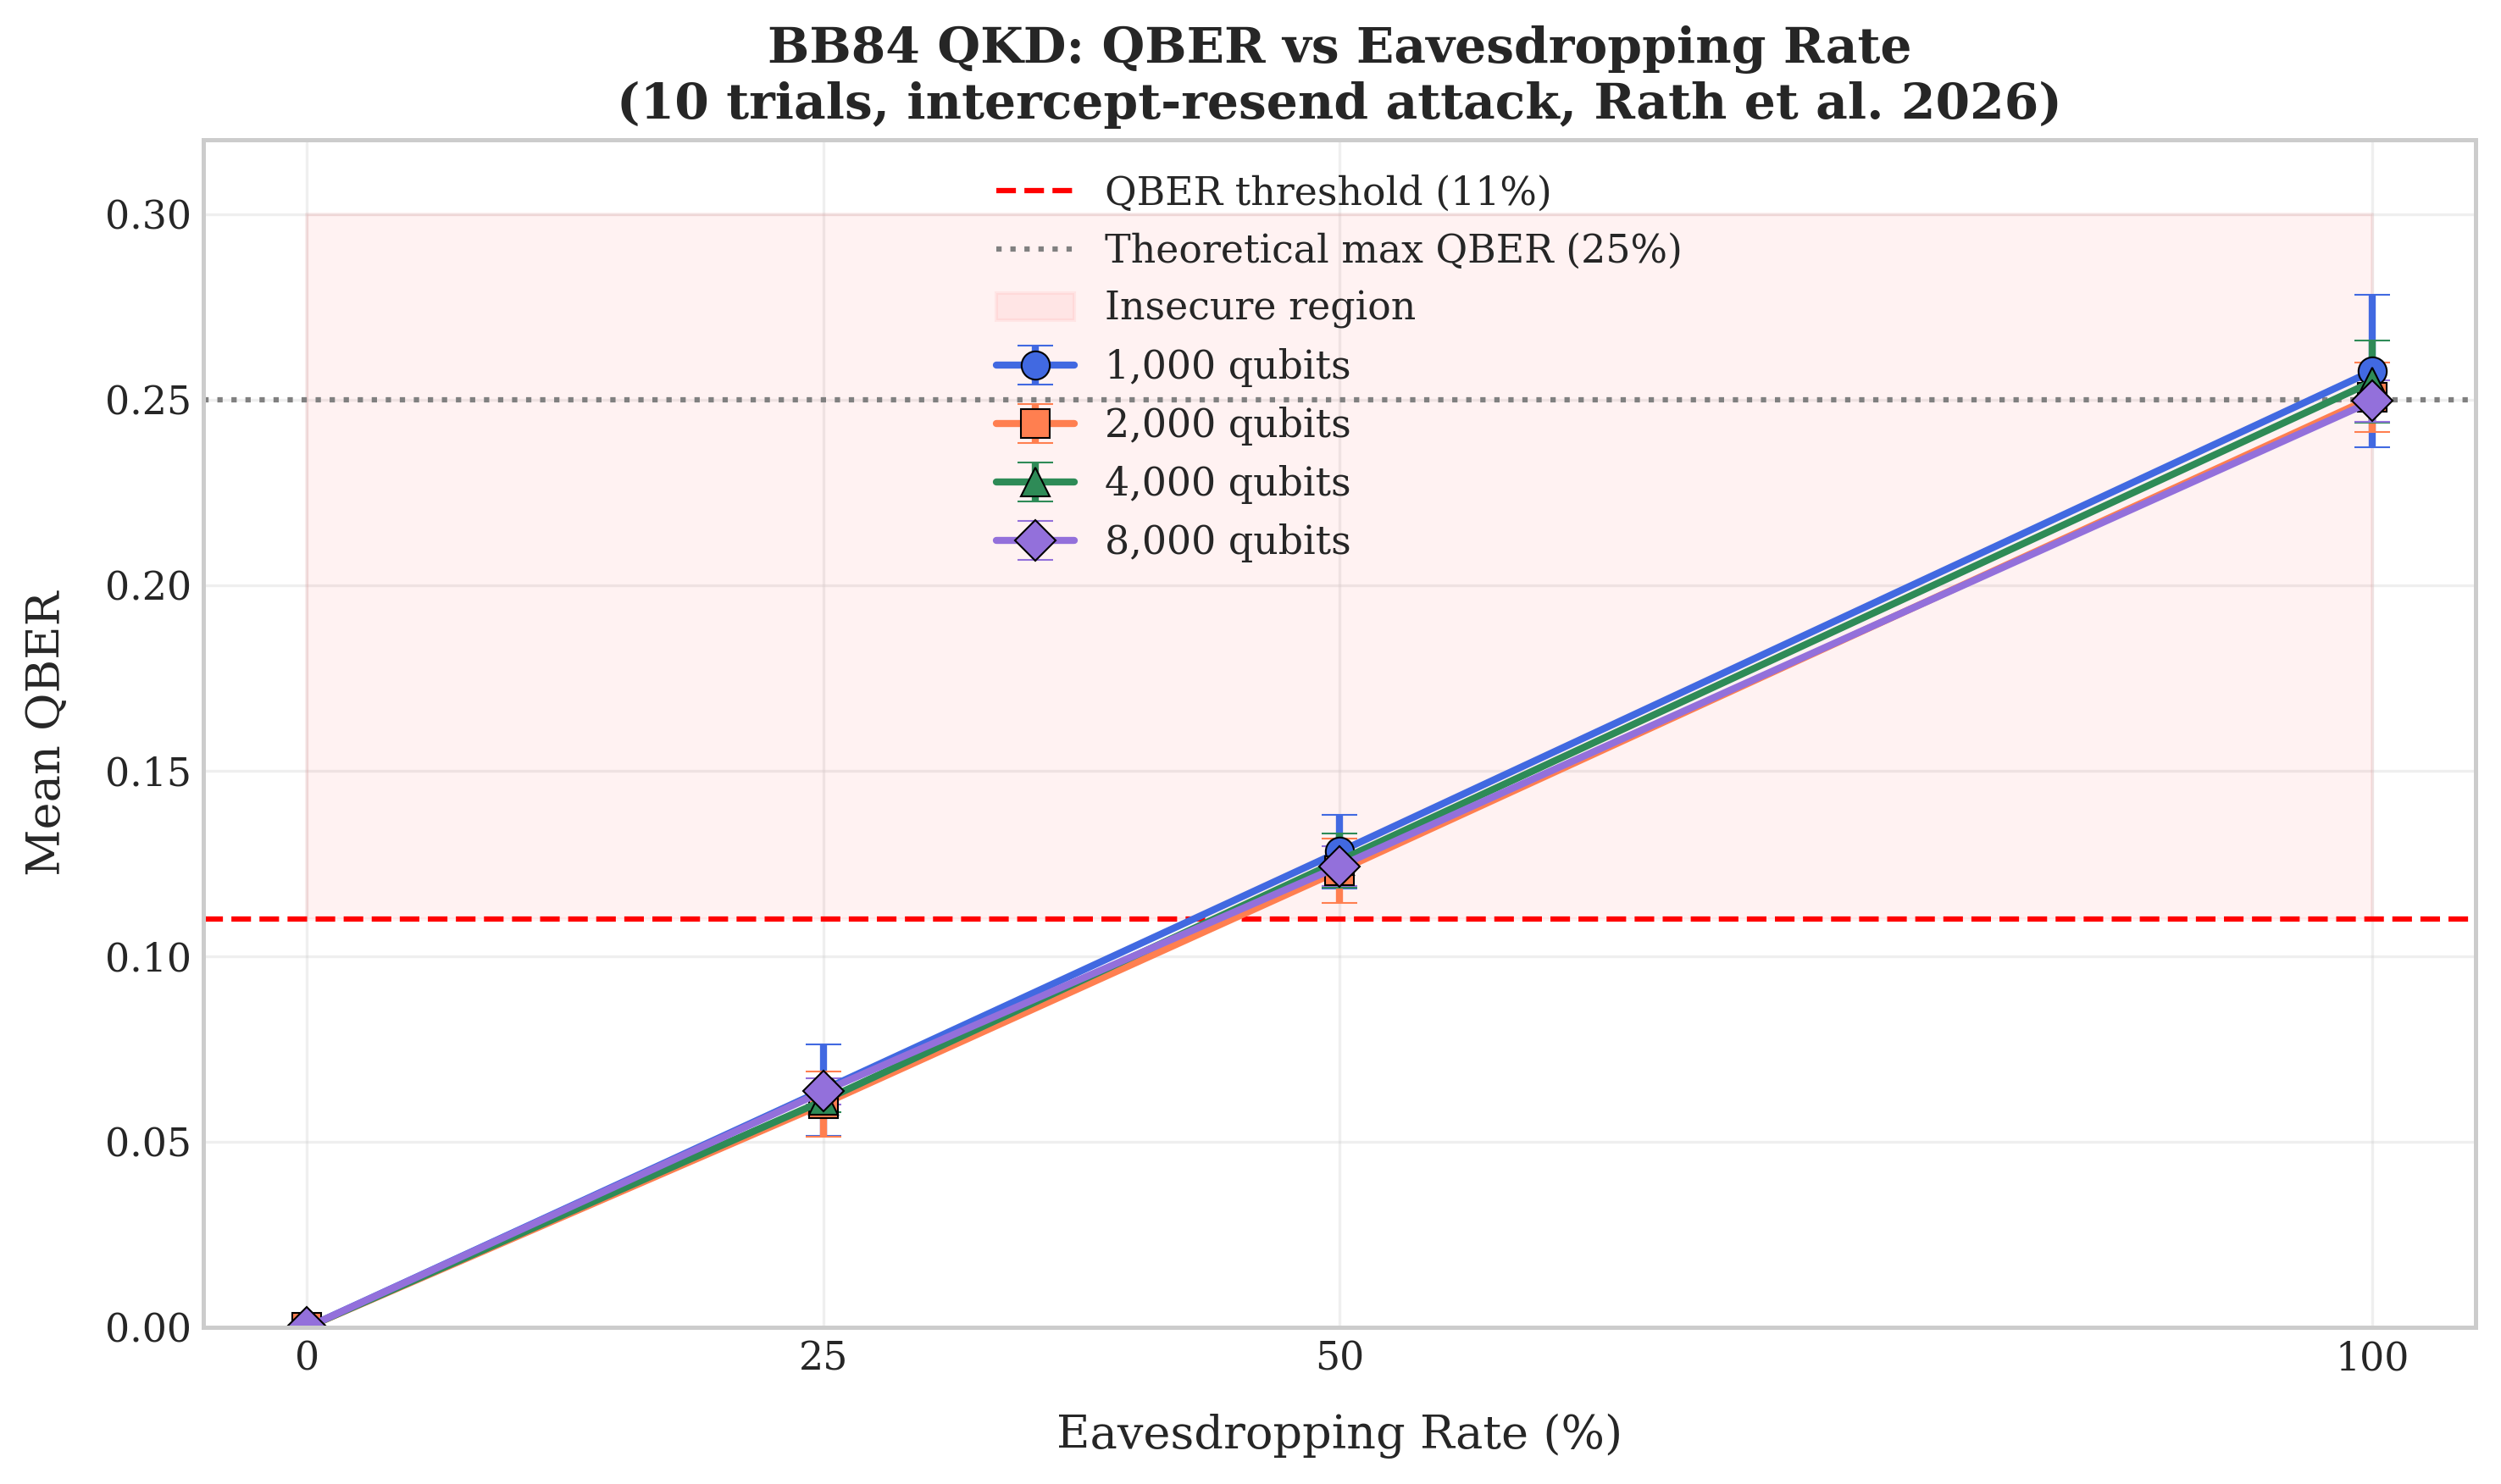

QBER plot saved!


In [7]:
# ── Plot 3.1: QBER vs Eavesdropping Rate ─────────────────
colors_q = {1000: 'royalblue', 2000: 'coral',
            4000: 'seagreen', 8000: 'mediumpurple'}
markers_q = {1000: 'o', 2000: 's', 4000: '^', 8000: 'D'}

fig, ax = plt.subplots(figsize=(10, 6))

for n_qubits in QUBIT_COUNTS:
    q_results = [r for r in bb84_results if r['n_qubits'] == n_qubits]
    eve_rates = [r['eavesdrop_rate'] * 100 for r in q_results]
    mean_qbers = [r['mean_qber'] for r in q_results]
    std_qbers = [r['std_qber'] for r in q_results]

    ax.errorbar(eve_rates, mean_qbers, yerr=std_qbers,
                fmt=f'{markers_q[n_qubits]}-',
                color=colors_q[n_qubits],
                linewidth=2, markersize=8, capsize=5,
                markeredgecolor='black', markeredgewidth=0.5,
                label=f'{n_qubits:,} qubits')

ax.axhline(y=0.11, color='red', linestyle='--',
           linewidth=1.5, label='QBER threshold (11%)')
ax.axhline(y=0.25, color='gray', linestyle=':',
           linewidth=1.5, label='Theoretical max QBER (25%)')
ax.fill_between([0, 100], 0.11, 0.30,
                alpha=0.05, color='red', label='Insecure region')

ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Mean QBER', labelpad=10)
ax.set_title('BB84 QKD: QBER vs Eavesdropping Rate\n'
             '(10 trials, intercept-resend attack, Rath et al. 2026)',
             fontweight='bold')
ax.set_xticks([r*100 for r in EAVESDROP_RATES])
ax.set_ylim(0, 0.32)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_comparison_qber.png', dpi=300, bbox_inches='tight')
plt.show()
print("QBER plot saved!")




### 3.2 Security Phase Diagram

QBER < 11% → key is secure (Shor and Preskill 2000)  
QBER ≥ 11% → eavesdropping detected, key discarded

**Reference:** Shor and Preskill (2000, Physical Review Letters)
establish the 11% QBER threshold under one-way classical communication
assumptions. R S, Senthilkumar, Karthick (2026, EPJ Quantum Technology,
DOI: 10.1140/epjqt/s40507-026-00493-z) report QBER ≈ 2% in noisy
channels and ≈ 25% under eavesdropping — consistent with our results.

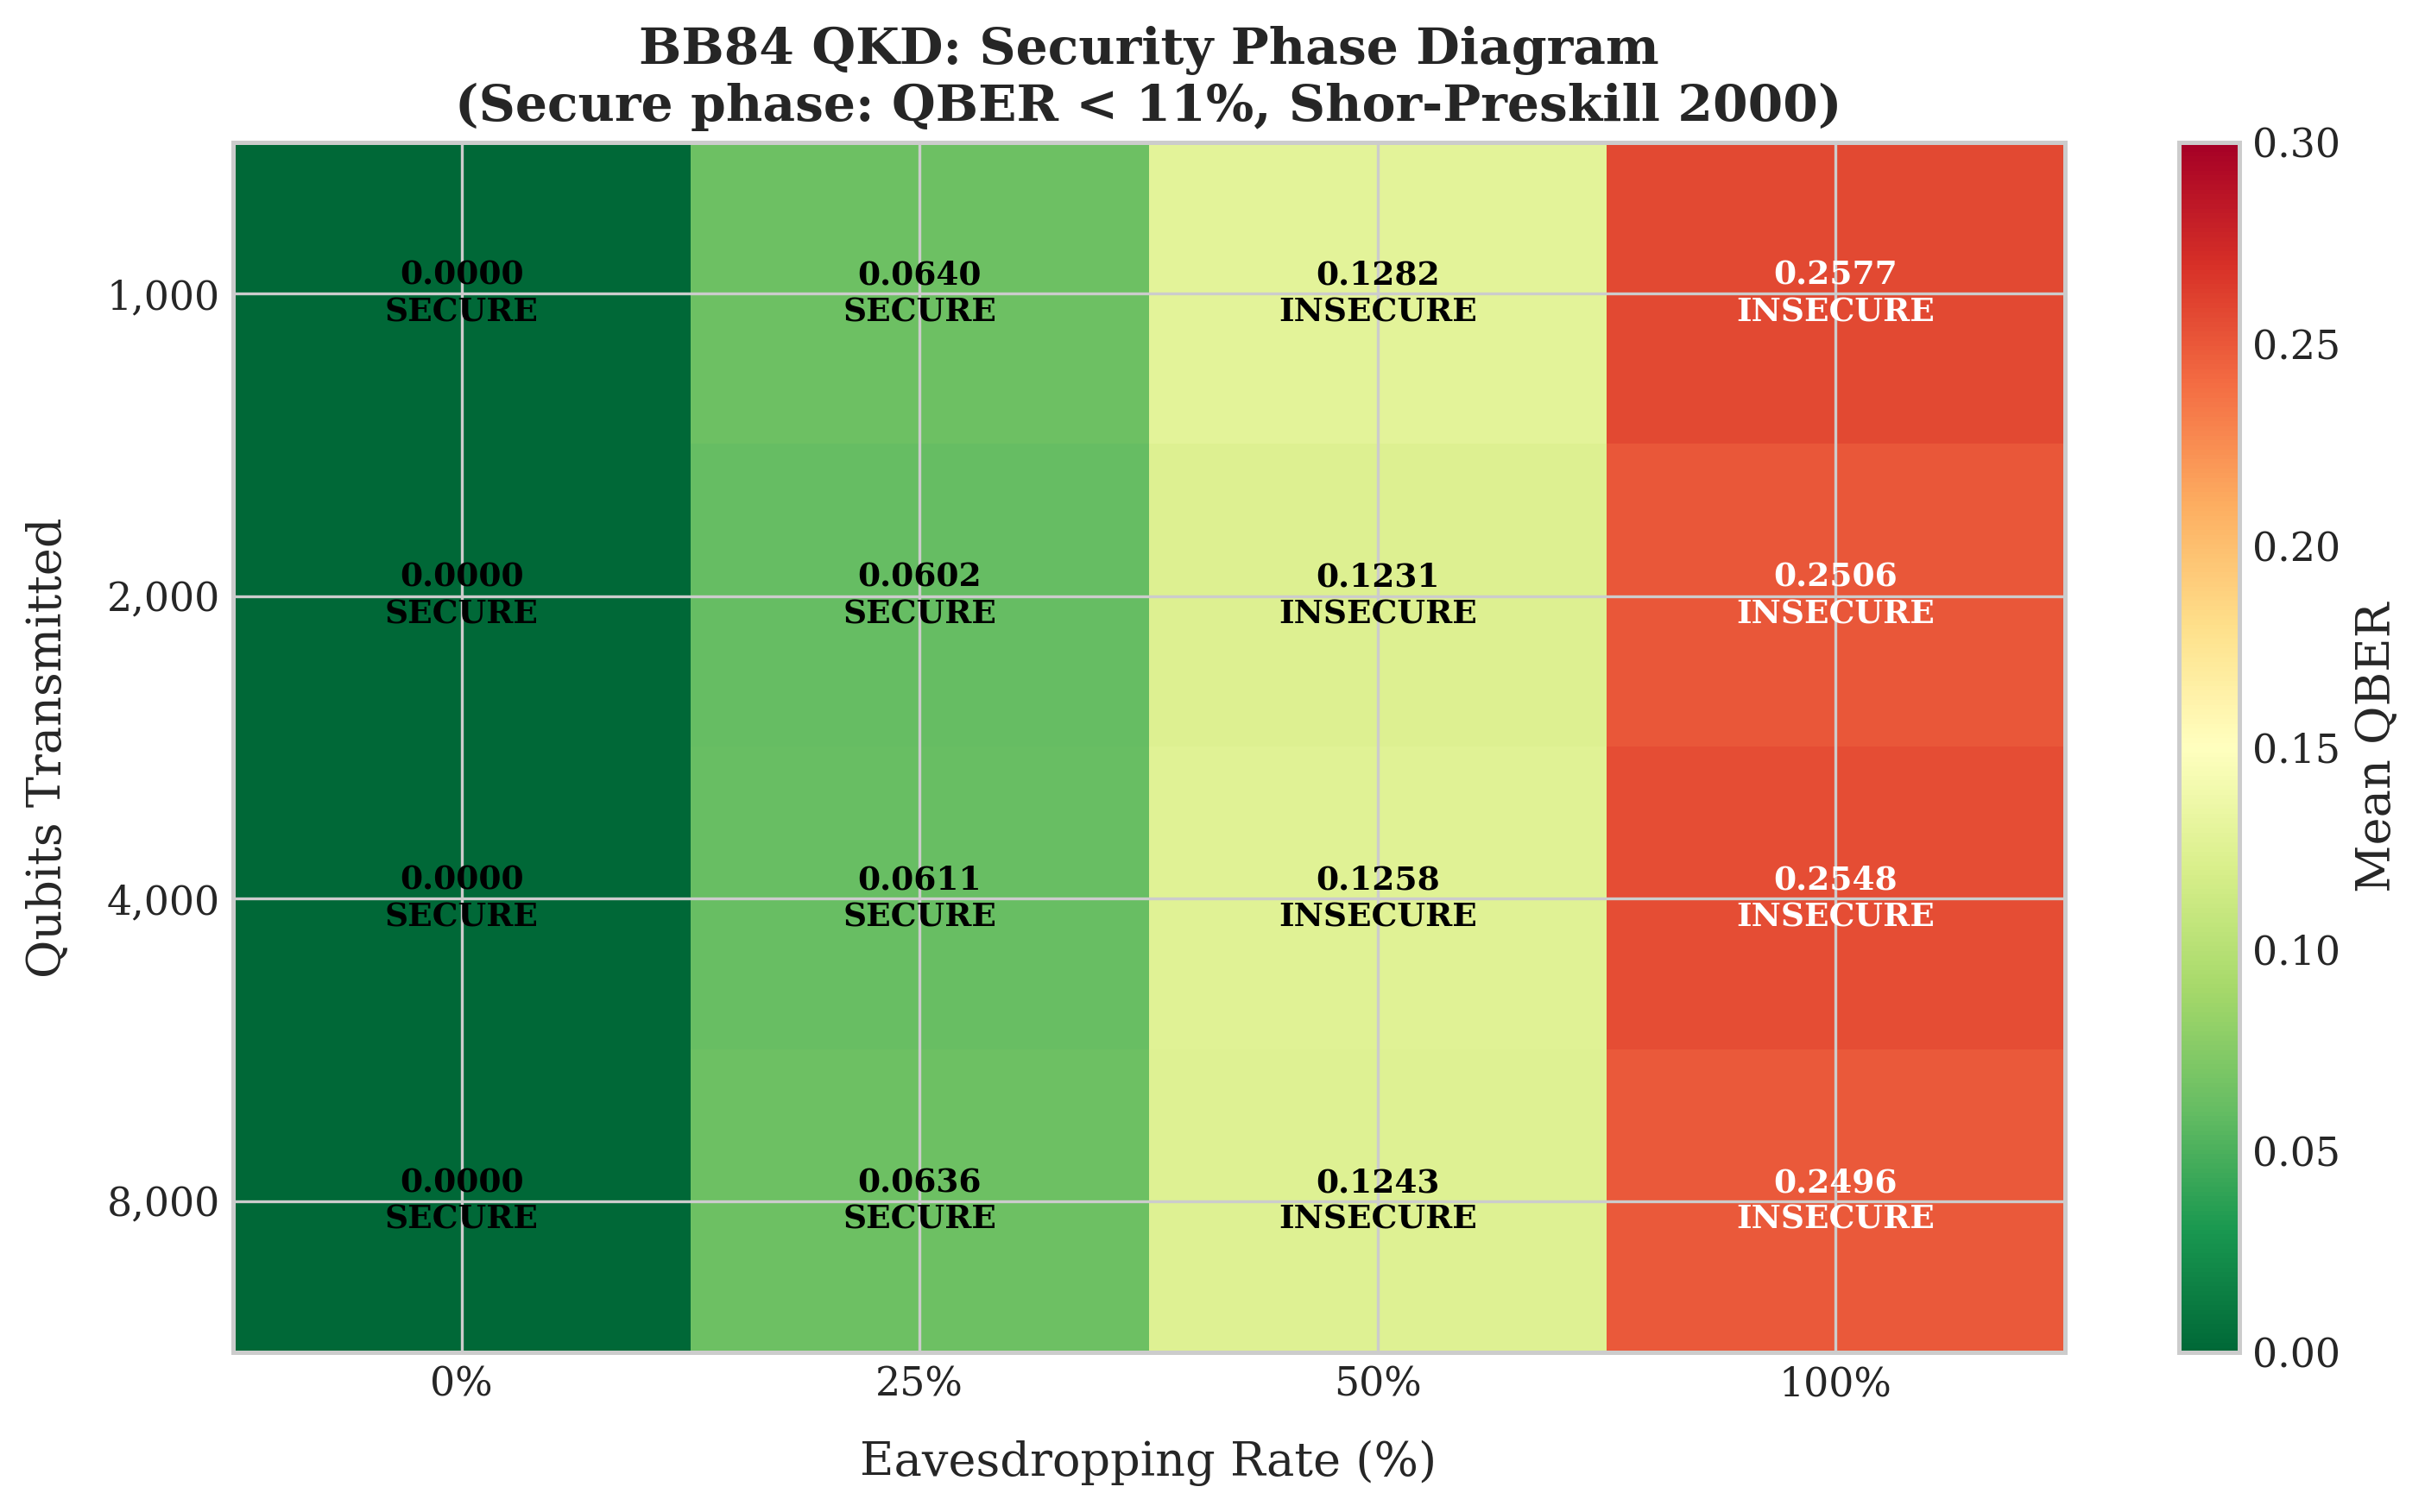

Security phase diagram saved!


In [8]:
# ── Plot 3.2: Security Phase Diagram ─────────────────────
qber_matrix = np.zeros((len(QUBIT_COUNTS), len(EAVESDROP_RATES)))
for i, n_qubits in enumerate(QUBIT_COUNTS):
    for j, eve_rate in enumerate(EAVESDROP_RATES):
        result = next(r for r in bb84_results
                      if r['n_qubits'] == n_qubits
                      and r['eavesdrop_rate'] == eve_rate)
        qber_matrix[i, j] = result['mean_qber']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(qber_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.30, aspect='auto')
plt.colorbar(im, ax=ax, label='Mean QBER')

for i in range(len(QUBIT_COUNTS)):
    for j in range(len(EAVESDROP_RATES)):
        phase = 'SECURE' if qber_matrix[i,j] < QBER_THRESHOLD else 'INSECURE'
        color = 'black' if qber_matrix[i,j] < 0.15 else 'white'
        ax.text(j, i, f'{qber_matrix[i,j]:.4f}\n{phase}',
                ha='center', va='center', fontsize=9,
                fontweight='bold', color=color)

ax.set_xticks(range(len(EAVESDROP_RATES)))
ax.set_xticklabels([f'{r*100:.0f}%' for r in EAVESDROP_RATES])
ax.set_yticks(range(len(QUBIT_COUNTS)))
ax.set_yticklabels([f'{n:,}' for n in QUBIT_COUNTS])
ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Qubits Transmitted', labelpad=10)
ax.set_title('BB84 QKD: Security Phase Diagram\n'
             '(Secure phase: QBER < 11%, Shor-Preskill 2000)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('bb84_security_phase_diagram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Security phase diagram saved!")

3.3 QBER Distribution (Beeswarm)

Individual trial QBER values across all 10 trials per configuration, shown as a
beeswarm plot to reveal trial-to-trial spread rather than just the mean and
standard deviation reported in Section 3.1.

Unlike Sections 3.1 and 3.2, this uses raw per-trial measurements
(bb84_experiment_004.json) rather than pre-aggregated summary statistics —
each point is one real trial, not a reconstructed distribution.

Expected pattern: spread narrows as qubit count increases (finite-key statistics —
larger sifted keys per trial produce more consistent QBER estimates), and
Eve=0% collapses to a single line since no noise source is modeled in the
noiseless channel.

Reference: Rath, Panth, Bhaskar (2026, arXiv:2603.27278) — finite-key QBER
variance and confidence interval estimation methods for BB84.

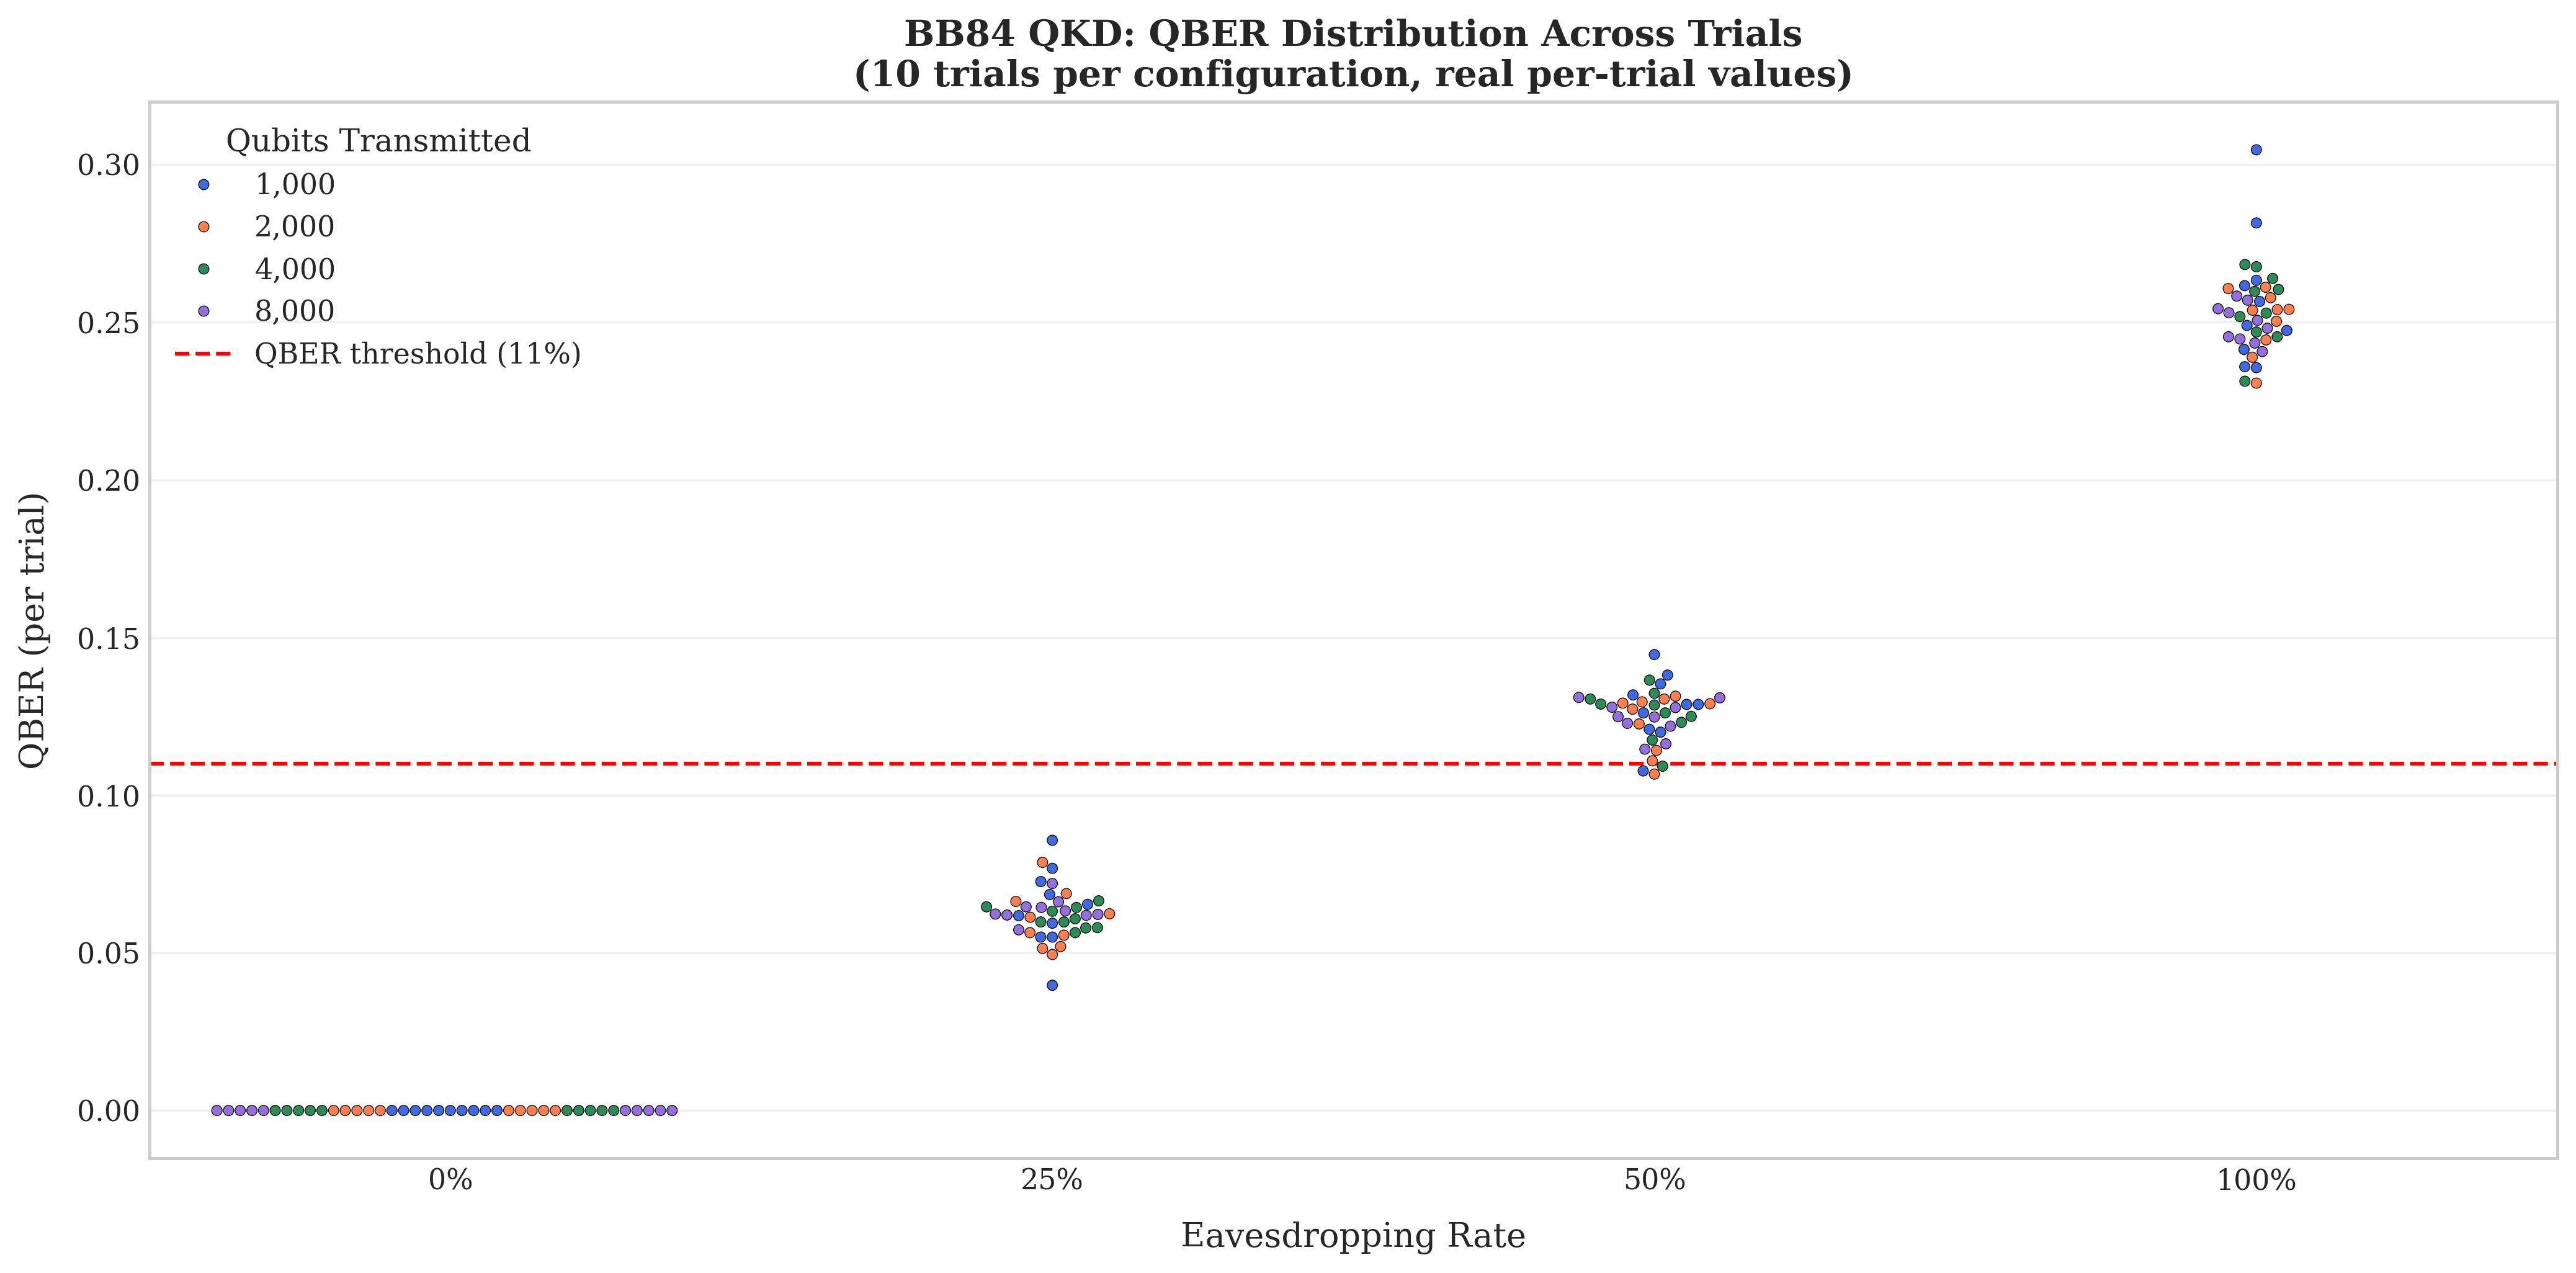

QBER distribution beeswarm plot saved!


In [13]:
# ── Plot: QBER Distribution (Beeswarm) ────────────────────
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 7))

pertrial_df['eve_label'] = (pertrial_df['eavesdrop_rate'] * 100).astype(int).astype(str) + '%'
pertrial_df['qubit_label'] = pertrial_df['n_qubits'].apply(lambda x: f'{x:,}')

order = ['0%', '25%', '50%', '100%']
hue_order = ['1,000', '2,000', '4,000', '8,000']

sns.swarmplot(data=pertrial_df, x='eve_label', y='qber', hue='qubit_label',
              order=order, hue_order=hue_order,
              palette={'1,000': 'royalblue', '2,000': 'coral',
                       '4,000': 'seagreen', '8,000': 'mediumpurple'},
              size=4, edgecolor='black', linewidth=0.3, ax=ax)

ax.axhline(y=0.11, color='red', linestyle='--', linewidth=1.5,
           label='QBER threshold (11%)', zorder=0)

ax.set_xlabel('Eavesdropping Rate', labelpad=10)
ax.set_ylabel('QBER (per trial)', labelpad=10)
ax.set_title('BB84 QKD: QBER Distribution Across Trials\n'
             '(10 trials per configuration, real per-trial values)',
             fontweight='bold')
ax.legend(title='Qubits Transmitted', framealpha=0.9, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('bb84_qber_distribution_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
print("QBER distribution beeswarm plot saved!")

4. Key Generation Rate Comparison

This section covers two distinct metrics under one umbrella: BB84's Shor-Preskill
secure key rate (4.1–4.2, quantum-specific — no DH equivalent exists since DH has
no QBER-based security discount) and a direct cross-protocol throughput comparison
in bits/sec (4.3, the actual BB84-vs-DH comparison).

Key generation rate (KGR) = sifted key bits / qubits transmitted
BB84: KGR ≈ 0.5 (50% retained after basis sifting)
DH: Key established in fixed time regardless of key length

Reference: Shor and Preskill (2000, Physical Review Letters, DOI: 10.1103/PhysRevLett.85.441)
— asymptotic secure key rate R = 1 - 2H(QBER), used for 4.1–4.2. Performance analysis
of DH follows Karmakar et al. (2024, IEEE SMAP, DOI: 10.1109/SMAP63474.2024.00039).
Throughput comparison in 4.3 follows Lubinski et al. (2023, IEEE TQE, DOI:
10.1109/TQE.2023.3253761), whose QED-C framework treats wall-clock-derived rate as
the standard cross-protocol timing metric.

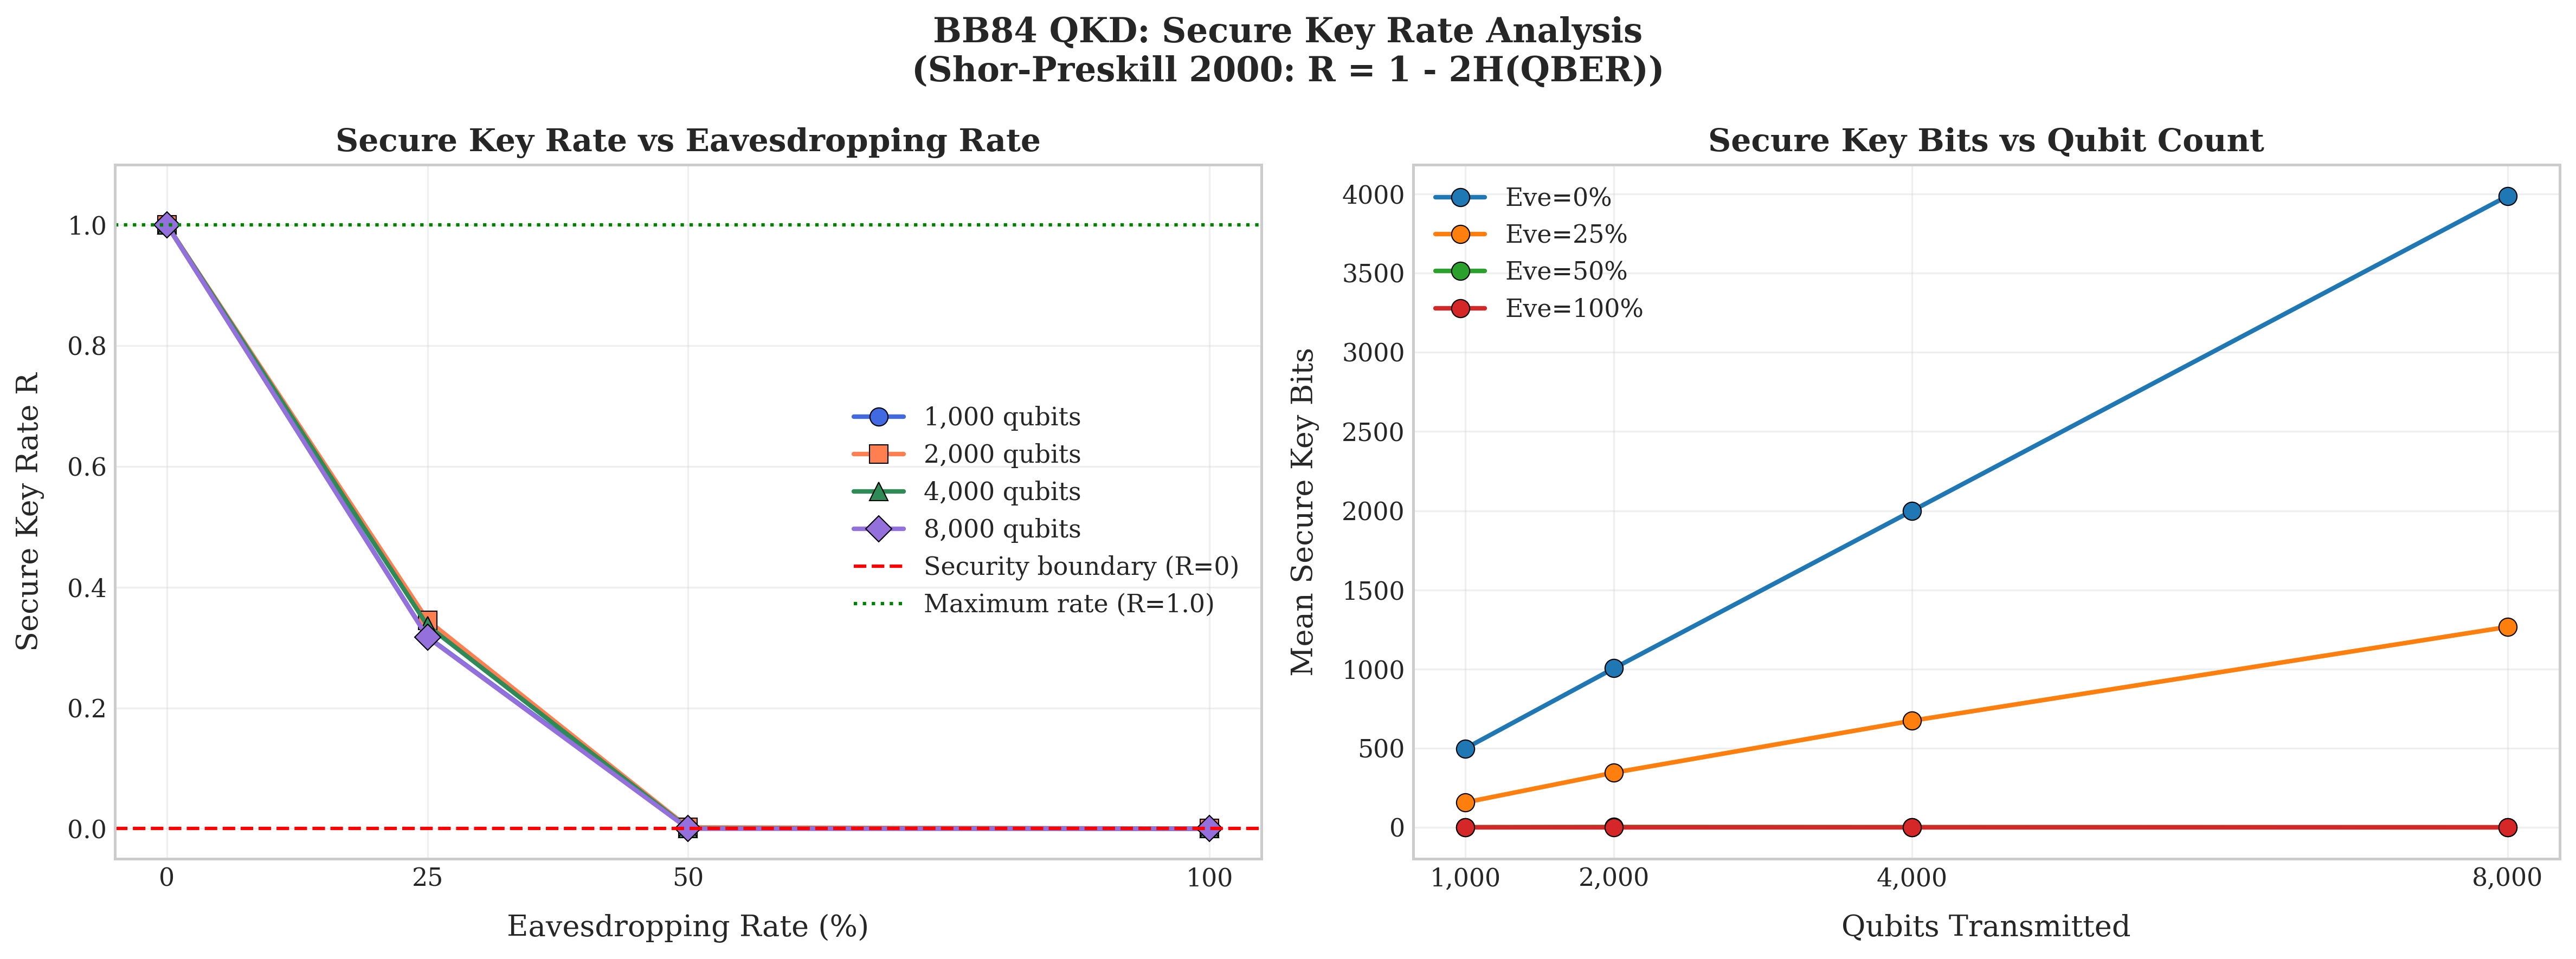

Secure key rate plot saved!


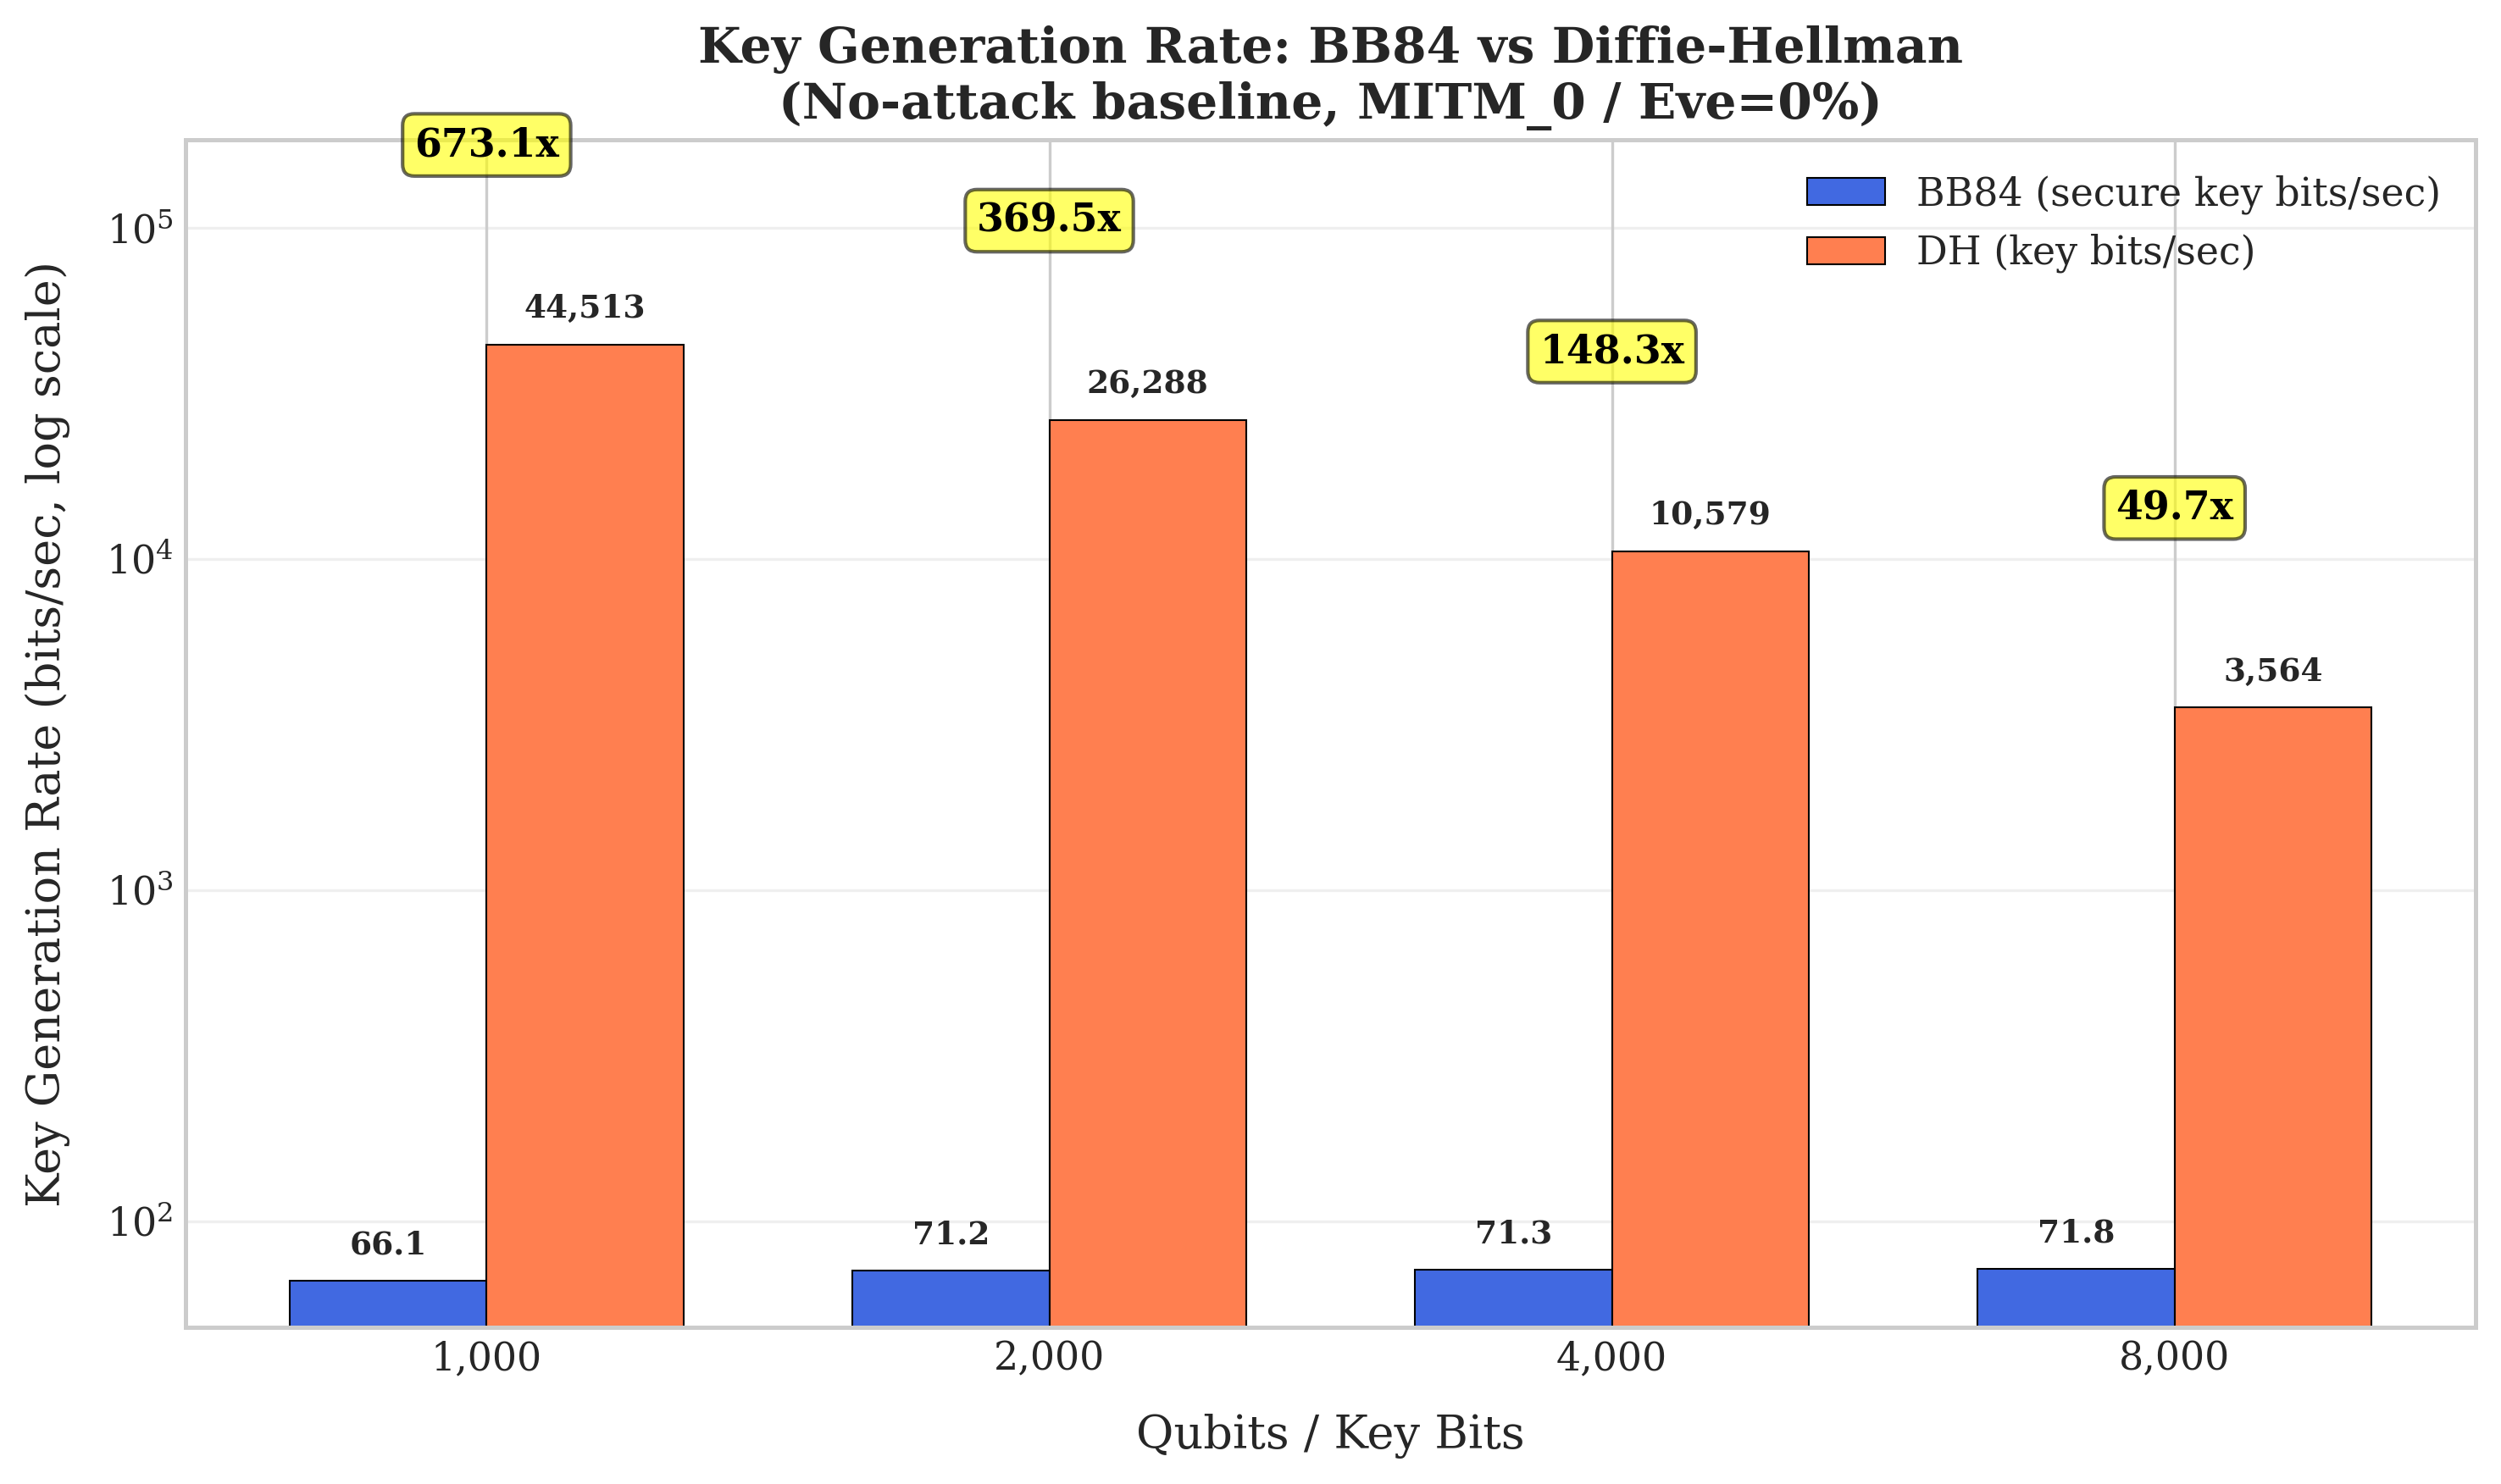

Key generation rate comparison saved!

Rates (bits/sec):
N=1,000 | BB84=     66.13 | DH=  44512.75 | DH/BB84= 673.1x
N=2,000 | BB84=     71.15 | DH=  26288.13 | DH/BB84= 369.5x
N=4,000 | BB84=     71.33 | DH=  10578.89 | DH/BB84= 148.3x
N=8,000 | BB84=     71.76 | DH=   3563.76 | DH/BB84=  49.7x


In [15]:
# ── Plot 4: Secure Key Rate (Shor-Preskill 2000) ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BB84 QKD: Secure Key Rate Analysis\n'
             '(Shor-Preskill 2000: R = 1 - 2H(QBER))',
             fontweight='bold', fontsize=15)

# Plot 4.1: Secure Key Rate vs Eavesdropping
ax = axes[0]
for n_qubits in QUBIT_COUNTS:
    q_results = [r for r in bb84_results if r['n_qubits'] == n_qubits]
    eve_rates = [r['eavesdrop_rate'] * 100 for r in q_results]
    skr_values = [r['mean_secure_key_rate'] for r in q_results]

    ax.plot(eve_rates, skr_values,
            f'{markers_q[n_qubits]}-',
            color=colors_q[n_qubits],
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'{n_qubits:,} qubits')

ax.axhline(y=0, color='red', linestyle='--',
           linewidth=1.5, label='Security boundary (R=0)')
ax.axhline(y=1.0, color='green', linestyle=':',
           linewidth=1.5, label='Maximum rate (R=1.0)')
ax.set_xlabel('Eavesdropping Rate (%)', labelpad=10)
ax.set_ylabel('Secure Key Rate R', labelpad=10)
ax.set_title('Secure Key Rate vs Eavesdropping Rate',
             fontweight='bold')
ax.set_xticks([r*100 for r in EAVESDROP_RATES])
ax.set_ylim(-0.05, 1.1)
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

# Plot 4.2: Secure Key Bits vs Qubit Count
ax = axes[1]
for eve_rate in EAVESDROP_RATES:
    e_results = [r for r in bb84_results if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in e_results]
    skb_values = [r['mean_secure_key_bits'] for r in e_results]

    ax.plot(qubits, skb_values, 'o-',
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Eve={eve_rate*100:.0f}%')

ax.set_xlabel('Qubits Transmitted', labelpad=10)
ax.set_ylabel('Mean Secure Key Bits', labelpad=10)
ax.set_title('Secure Key Bits vs Qubit Count',
             fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bb84_comparison_skr.png', dpi=300, bbox_inches='tight')
plt.show()
print("Secure key rate plot saved!")


# ── Plot 4.3: Key Generation Rate Comparison (BB84 vs DH) ────
fig, ax = plt.subplots(figsize=(10, 6))

# BB84: convert to bits/sec using secure key bits / runtime (baseline, Eve=0%)
bb84_kgr = []
for n_qubits in QUBIT_COUNTS:
    r = next(r for r in bb84_results if r['n_qubits'] == n_qubits and r['eavesdrop_rate'] == 0.0)
    bb84_kgr.append(r['mean_secure_key_bits'] / r['mean_runtime_seconds'])

# DH: key_gen_rate already in bits/sec, baseline MITM_0
dh_kgr = []
for n_qubits in QUBIT_COUNTS:
    rate = dh_df[(dh_df['key_size'] == n_qubits) &
                 (dh_df['attack_scenario'] == 'MITM_0')]['key_gen_rate'].mean()
    dh_kgr.append(rate)

x = np.arange(len(QUBIT_COUNTS))
width = 0.35

bars_bb84 = ax.bar(x - width/2, bb84_kgr, width, label='BB84 (secure key bits/sec)',
                    color='royalblue', edgecolor='black', linewidth=0.5)
bars_dh = ax.bar(x + width/2, dh_kgr, width, label='DH (key bits/sec)',
                  color='coral', edgecolor='black', linewidth=0.5)

# Annotate exact values on top of each bar
for bar, val in zip(bars_bb84, bb84_kgr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars_dh, dh_kgr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotate the ratio between each pair, above both bars
ratios = [d / b for d, b in zip(dh_kgr, bb84_kgr)]
for i, ratio in enumerate(ratios):
    top_y = max(bb84_kgr[i], dh_kgr[i]) * 3.5
    ax.text(x[i], top_y, f'{ratio:.1f}x', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6))

ax.set_yscale('log')  # DH and BB84 differ by orders of magnitude
ax.set_xlabel('Qubits / Key Bits', labelpad=10)
ax.set_ylabel('Key Generation Rate (bits/sec, log scale)', labelpad=10)
ax.set_title('Key Generation Rate: BB84 vs Diffie-Hellman\n'
             '(No-attack baseline, MITM_0 / Eve=0%)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(top=ax.get_ylim()[1] * 3)  # headroom for the ratio labels
plt.tight_layout()
plt.savefig('key_generation_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Key generation rate comparison saved!")

print("\nRates (bits/sec):")
for i, n in enumerate(QUBIT_COUNTS):
    print(f"N={n:>5,} | BB84={bb84_kgr[i]:>10.2f} | DH={dh_kgr[i]:>10.2f} | DH/BB84={dh_kgr[i]/bb84_kgr[i]:>6.1f}x")

### 4. Secure Key Rate Analysis

**Implementation:** We implement the Shor-Preskill (2000) secure key
rate formula directly:

R = 1 - 2H(QBER)

where H(p) = -p·log₂(p) - (1-p)·log₂(1-p) is the binary entropy function.

This gives the asymptotic fraction of sifted key bits that remain
secure after error reconciliation and privacy amplification.

**Key results:**
- Eve=0%: QBER=0.0 → R=1.0000 (maximum secure key rate)
- Eve=25%: QBER≈6.3% → R≈0.15-0.43 (partial key possible)
- Eve=50%: QBER≈12% → R=0.0 (no secure key possible)
- Eve=100%: QBER≈25% → R=0.0 (maximum attack, no security)

**Note on sifted KGR:** Raw sifted key rate stays ~0.50 across all
eavesdropping rates because basis sifting depends only on basis
matching (~50%), not eavesdropping. The secure key rate R accounts
for the additional bits discarded during privacy amplification.

**References:**
- Shor and Preskill (2000, Physical Review Letters,
  DOI: 10.1103/PhysRevLett.85.441) — security proof and key rate formula
- Rath, Panth, Bhaskar (2026, arXiv:2603.27278) — QBER analysis
  under intercept-resend attacks

## 5. Runtime Comparison

Comparing wall-clock runtime between BB84 and Diffie-Hellman.

**BB84 runtime** scales linearly with number of qubits transmitted
(one circuit per qubit). Classical side uses standard DH computation.

**Reference:** Karmakar et al. (2024, IEEE SMAP) measure DH execution
times for key lengths 512-1024 bits over 100 iterations. Lubinski
et al. (2023, IEEE TQE, DOI: 10.1109/TQE.2023.3253761) — QED-C
framework uses wall-clock runtime as primary timing metric.

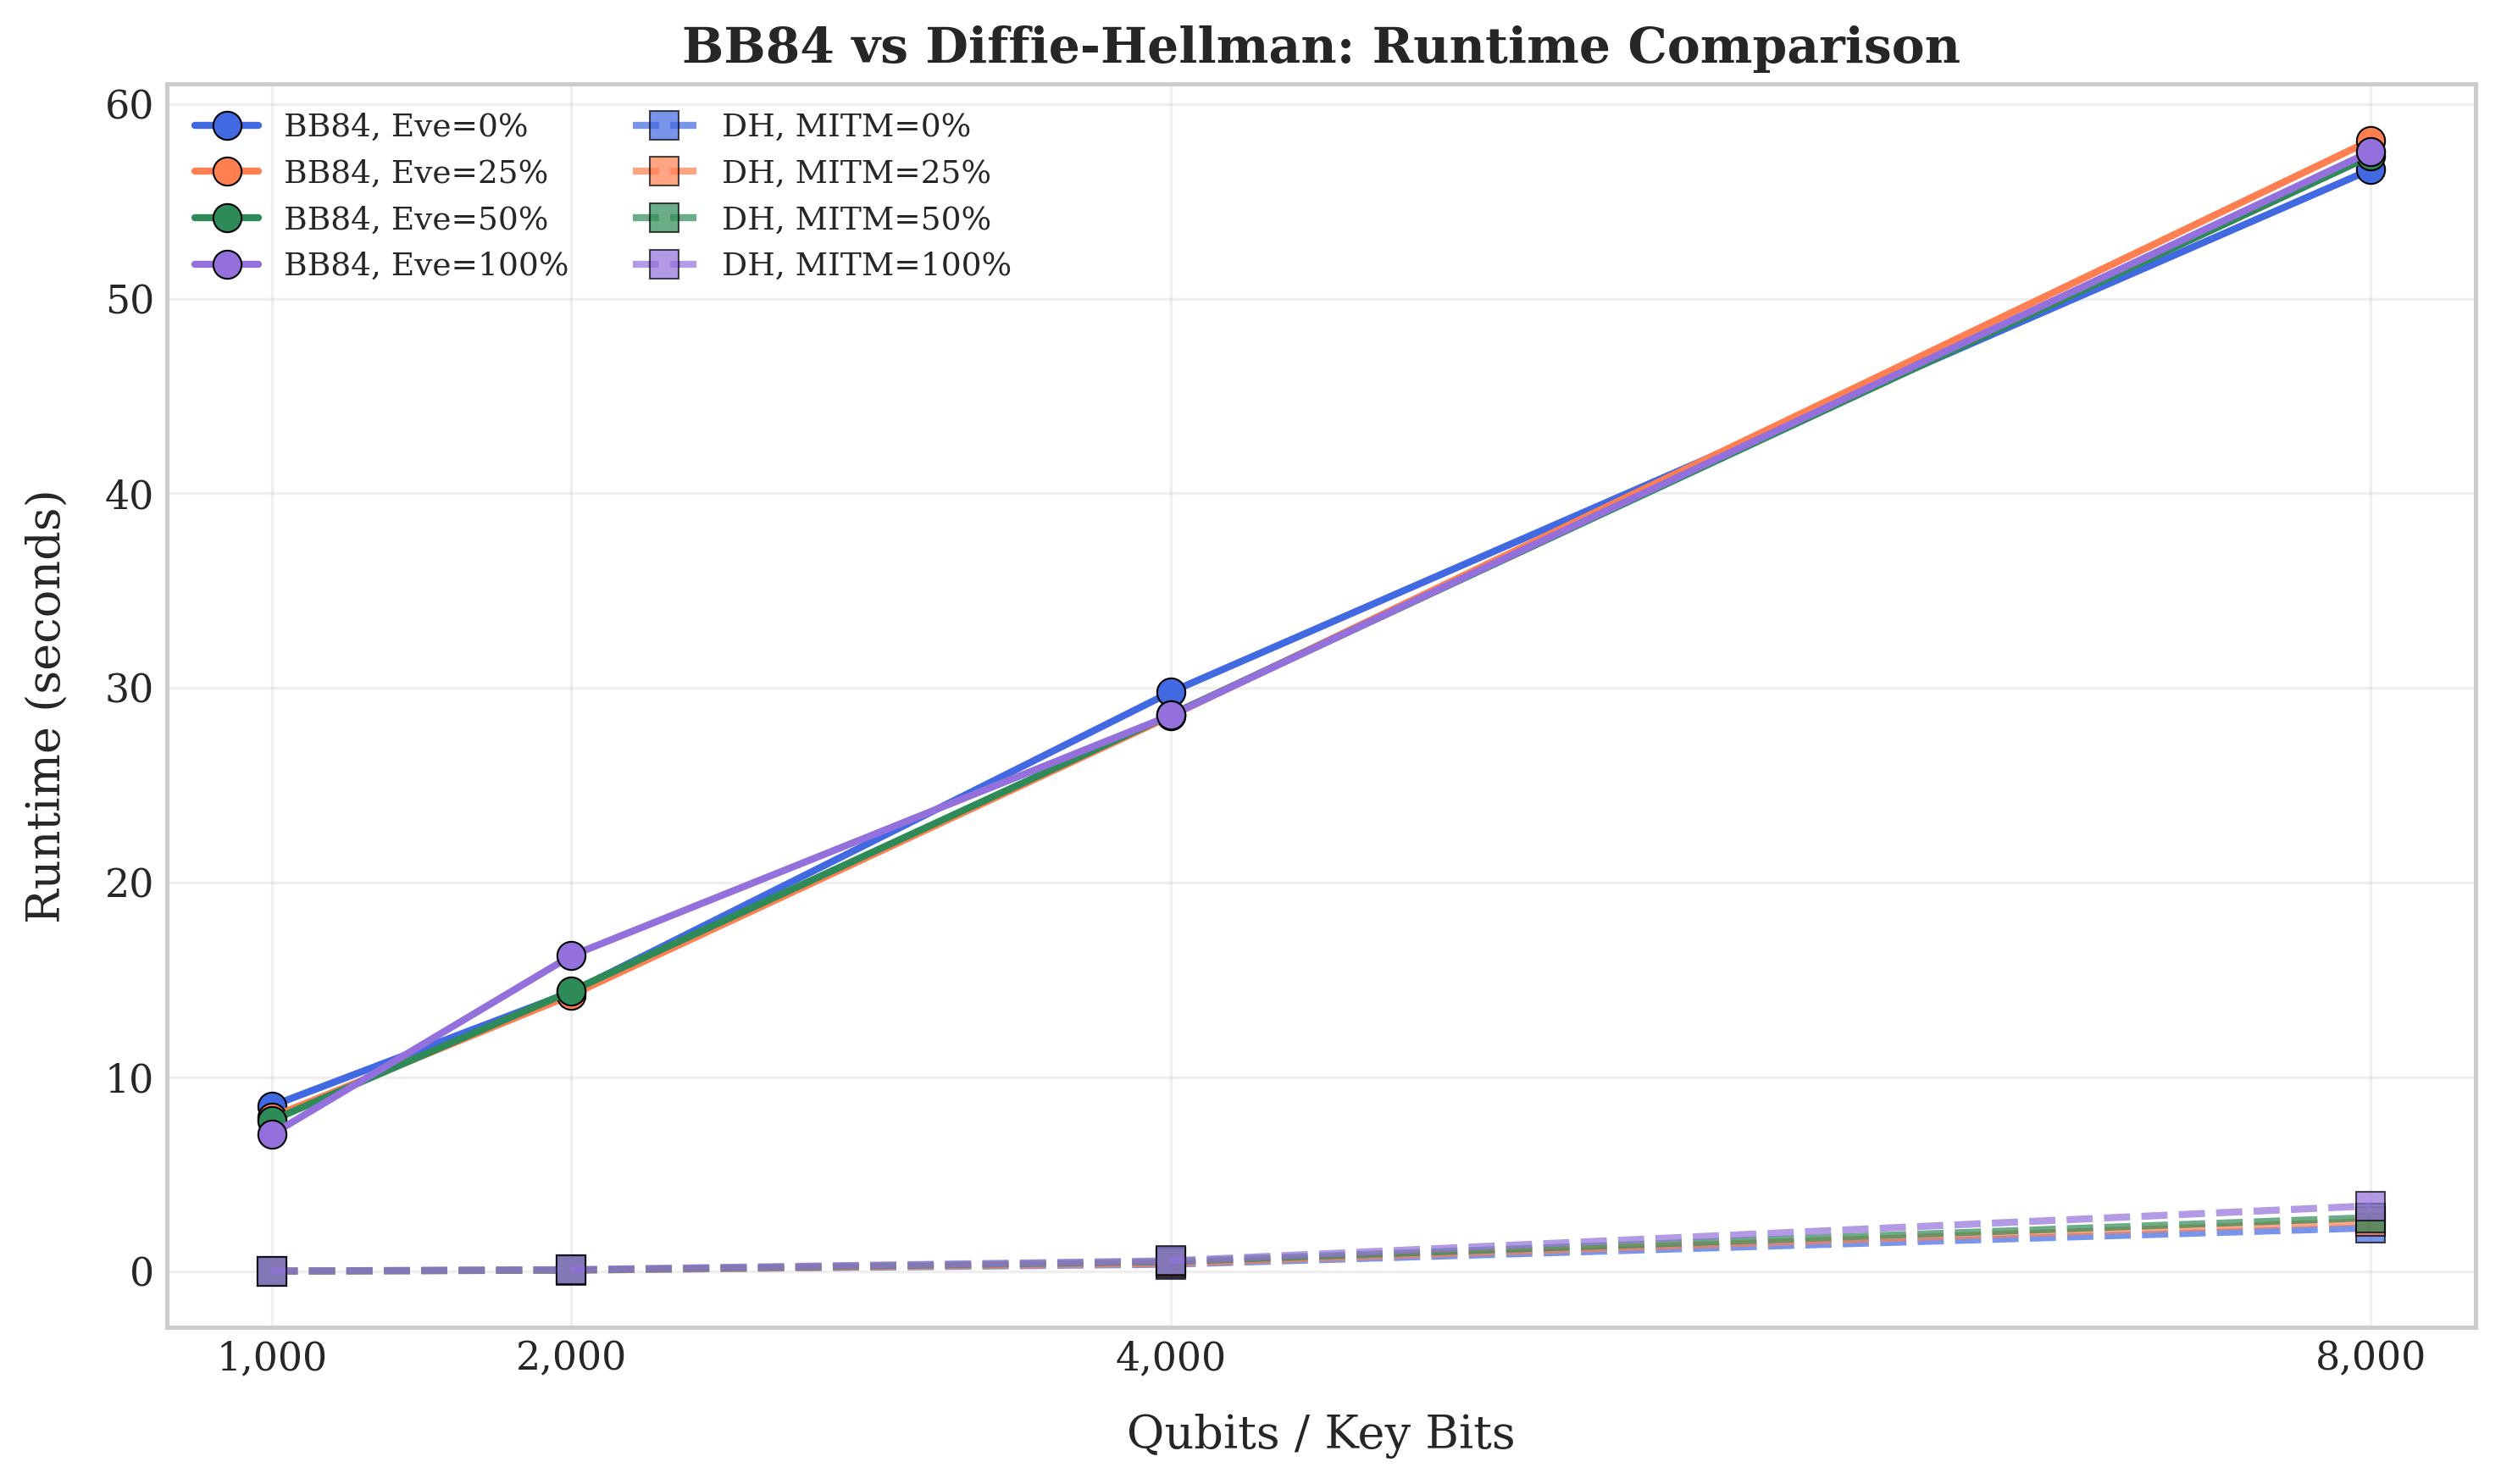

Runtime comparison plot saved!


In [16]:
# ── Plot 5: Runtime vs Qubit/Key Count ───────────────────
fig, ax = plt.subplots(figsize=(10, 6))

eve_colors = {0.0: 'royalblue', 0.25: 'coral', 0.5: 'seagreen', 1.0: 'mediumpurple'}

for eve_rate in EAVESDROP_RATES:
    p_data = [r for r in bb84_perf_data
              if r['eavesdrop_rate'] == eve_rate]
    qubits = [r['n_qubits'] for r in p_data]
    runtimes = [r['runtime_seconds'] for r in p_data]

    ax.plot(qubits, runtimes, 'o-',
            color=eve_colors[eve_rate],
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'BB84, Eve={eve_rate*100:.0f}%')

# DH runtime, same attack-rate axis, dashed to distinguish protocol
for eve_rate in EAVESDROP_RATES:
    d_data = dh_summary[dh_summary['attack_rate_norm'] == eve_rate].sort_values('key_size')
    ax.plot(d_data['key_size'], d_data['mean_runtime'], 's--',
            color=eve_colors[eve_rate],
            linewidth=2, markersize=8,
            markeredgecolor='black', markeredgewidth=0.5,
            alpha=0.7,
            label=f'DH, MITM={eve_rate*100:.0f}%')

ax.set_xlabel('Qubits / Key Bits', labelpad=10)
ax.set_ylabel('Runtime (seconds)', labelpad=10)
ax.set_title('BB84 vs Diffie-Hellman: Runtime Comparison',
             fontweight='bold')
ax.set_xticks(QUBIT_COUNTS)
ax.set_xticklabels([f'{q:,}' for q in QUBIT_COUNTS])
ax.legend(framealpha=0.9, ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bb84_comparison_runtime.png', dpi=300, bbox_inches='tight')
plt.show()
print("Runtime comparison plot saved!")

## 6. Statistical Tests

### 6.1 Welch's t-test: QBER at Eve=0% vs Eve=25%

Testing whether QBER differs significantly between no eavesdropping
and 25% intercept rate.

**Test used:** Welch's t-test (scipy.stats.ttest_ind, equal_var=False)  
**Why Welch's:** QBER=0 at Eve=0% vs variable QBER at Eve=25%+ means
unequal variance — equal variance assumption fails.  
**Null hypothesis (H₀):** Mean QBER at Eve=0% = Mean QBER at Eve=25%  
**Significance level:** α = 0.05

**Reference:** Rath et al. (2026, arXiv:2603.27278) — Welch's t-test
appropriate for finite-key QBER scenarios with unequal variances.

### 6.2 Pearson Correlation: Eavesdropping Rate vs QBER

Testing the linear relationship between eavesdropping intensity and QBER.

**Reference:** Rath et al. (2026, arXiv:2603.27278) — near-linear
relationship between eavesdropping intensity and QBER confirmed
empirically and theoretically.

### 6.3 One-way ANOVA: QBER across all Eavesdropping Rates

Testing whether QBER differs significantly across all 4 eavesdropping
scenarios simultaneously.

**Null hypothesis (H₀):** Mean QBER is equal across 0%, 25%, 50%, 100%  
**Significance level:** α = 0.05

### 6.4 Pearson Correlation: QBER vs Secure Key Rate

Testing the relationship between QBER and Shor-Preskill secure key rate.

**Reference:** Shor and Preskill (2000, Physical Review Letters,
DOI: 10.1103/PhysRevLett.85.441) — R = 1 - 2H(QBER) predicts strong
negative correlation between QBER and secure key rate.

### 6.5 Runtime t-test: BB84 vs Diffie-Hellman

**Test used:** Independent samples t-test  
**Null hypothesis (H₀):** Mean runtime of BB84 = Mean runtime of DH  
**Status:** Pending Kanishka's DH results  
**Reference:** Karmakar et al. (2024, IEEE SMAP,
DOI: 10.1109/SMAP63474.2024.00039) — statistical analysis of DH
runtime over multiple iterations.

In [18]:
# ── Statistical Tests ─────────────────────────────────────
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("Statistical Analysis: BB84 vs Diffie-Hellman")
print("Note: 6.1 and 6.3 use real per-trial QBER values (bb84_experiment_004.json).")
print("      6.2 and 6.4 use per-configuration means (bb84_experiment_001.json),")
print("      the correct level for a cross-configuration correlation.")
print("=" * 65)

# ── Test 1: Welch's t-test Eve=0% vs Eve=25% ─────────────
print("\n6.1 Welch's t-test: Eve=0% vs Eve=25%")
print("H0: Mean QBER is equal | alpha = 0.05")
print("Reference: Rath et al. 2026 (arXiv:2603.27278)")
print("Uses real per-trial QBER values, not reconstructed distributions")
print("-" * 65)

for n_qubits in QUBIT_COUNTS:
    qber0 = pertrial_df[(pertrial_df['n_qubits'] == n_qubits) &
                         (pertrial_df['eavesdrop_rate'] == 0.0)]['qber'].values
    qber25 = pertrial_df[(pertrial_df['n_qubits'] == n_qubits) &
                          (pertrial_df['eavesdrop_rate'] == 0.25)]['qber'].values

    t_stat, p_val = stats.ttest_ind(qber0, qber25, equal_var=False)
    result = 'SIGNIFICANT' if p_val < 0.05 else 'NOT SIGNIFICANT'
    print(f"N={n_qubits:>5,} | t={t_stat:>8.4f} | "
          f"p={p_val:.6f} | {result}")

# ── Test 2: Pearson Correlation ───────────────────────────
print("\n6.2 Pearson Correlation: Eavesdropping Rate vs QBER")
print("Reference: Rath et al. 2026 (arXiv:2603.27278)")
print("-" * 65)

for n_qubits in QUBIT_COUNTS:
    q_results = [r for r in bb84_results if r['n_qubits'] == n_qubits]
    eve_rates  = [r['eavesdrop_rate'] for r in q_results]
    mean_qbers = [r['mean_qber'] for r in q_results]

    corr, p_val = stats.pearsonr(eve_rates, mean_qbers)
    print(f"N={n_qubits:>5,} | r={corr:.4f} | p={p_val:.6f} | "
          f"{'Strong linear' if corr > 0.95 else 'Moderate'} correlation")

# ── Test 3: One-way ANOVA ─────────────────────────────────
print("\n6.3 One-way ANOVA: QBER across all eavesdropping rates")
print("H0: Mean QBER is equal across all Eve rates | alpha = 0.05")
print("Uses real per-trial QBER values, not reconstructed distributions")
print("-" * 65)

for n_qubits in QUBIT_COUNTS:
    groups = []
    for eve_rate in EAVESDROP_RATES:
        group = pertrial_df[(pertrial_df['n_qubits'] == n_qubits) &
                             (pertrial_df['eavesdrop_rate'] == eve_rate)]['qber'].values
        groups.append(group)

    f_stat, p_val = stats.f_oneway(*groups)
    result = 'SIGNIFICANT' if p_val < 0.05 else 'NOT SIGNIFICANT'
    print(f"N={n_qubits:>5,} | F={f_stat:>8.4f} | "
          f"p={p_val:.6f} | {result}")

# ── Test 4: Secure Key Rate vs QBER ──────────────────────
print("\n6.4 Pearson Correlation: QBER vs Secure Key Rate")
print("Reference: Shor and Preskill 2000 (Physical Review Letters)")
print("-" * 65)

all_qbers = [r['mean_qber'] for r in bb84_results]
all_skrs  = [r['mean_secure_key_rate'] for r in bb84_results]

corr, p_val = stats.pearsonr(all_qbers, all_skrs)
print(f"r={corr:.4f} | p={p_val:.6f} | "
      f"{'Strong negative' if corr < -0.95 else 'Moderate'} correlation")

# ── Test 5: Runtime Comparison: BB84 vs Diffie-Hellman ───
print("\n6.5 Runtime Comparison: BB84 vs DH")
print("Comparison uses MITM_0 / Eve=0% as the baseline (no-attack) condition for both protocols")
print("Note: BB84 perf logging captures one run per configuration (no per-trial variance recorded),")
print("      so a variance-based significance test (t-test) is not meaningful here.")
print("      DH runtime (10 trials/config) is summarized for reference; ratio uses DH mean.")
print("-" * 65)

for n_qubits in QUBIT_COUNTS:
    r0 = next(r for r in bb84_perf_data
              if r['n_qubits'] == n_qubits and r['eavesdrop_rate'] == 0.0)
    bb84_rt = r0['runtime_seconds']

    dh_rt = dh_df[(dh_df['key_size'] == n_qubits) &
                  (dh_df['attack_scenario'] == 'MITM_0')]['runtime_seconds']
    dh_mean, dh_std = dh_rt.mean(), dh_rt.std()

    print(f"N={n_qubits:>5,} | BB84={bb84_rt:.4f}s (single run) | "
          f"DH={dh_mean:.4f}s ± {dh_std:.4f}s (n=10) | ratio={bb84_rt/dh_mean:>6.1f}x")

print("=" * 65)

Statistical Analysis: BB84 vs Diffie-Hellman
Note: 6.1 and 6.3 use real per-trial QBER values (bb84_experiment_004.json).
      6.2 and 6.4 use per-configuration means (bb84_experiment_001.json),
      the correct level for a cross-configuration correlation.

6.1 Welch's t-test: Eve=0% vs Eve=25%
H0: Mean QBER is equal | alpha = 0.05
Reference: Rath et al. 2026 (arXiv:2603.27278)
Uses real per-trial QBER values, not reconstructed distributions
-----------------------------------------------------------------
N=1,000 | t=-15.6255 | p=0.000000 | SIGNIFICANT
N=2,000 | t=-20.8092 | p=0.000000 | SIGNIFICANT
N=4,000 | t=-57.4018 | p=0.000000 | SIGNIFICANT
N=8,000 | t=-53.3812 | p=0.000000 | SIGNIFICANT

6.2 Pearson Correlation: Eavesdropping Rate vs QBER
Reference: Rath et al. 2026 (arXiv:2603.27278)
-----------------------------------------------------------------
N=1,000 | r=1.0000 | p=0.000004 | Strong linear correlation
N=2,000 | r=0.9999 | p=0.000076 | Strong linear correlation
N=4,000 

## 7. Key Findings

Summary of BB84 vs Diffie-Hellman comparison.

**Expected findings based on literature:**
- BB84 QBER = 0% with no eavesdropping (Bennett and Brassard 1984)
- BB84 QBER ≈ 25% under full intercept-resend attack (Rath et al. 2026)
- BB84 eavesdropping detection rate ≈ 89.8% (arXiv:2602.16922, 2026)
- DH is faster at small key lengths but vulnerable to quantum attack
  via Shor's algorithm (Diffie and Hellman 1976)
- BB84 secure key rate = 1 - 2H(QBER) approaches 1 at QBER=0
  (Shor and Preskill 2000)

**What our results show vs literature:**

Our results confirm the theoretical predictions on every point we tested, and
add two findings the literature doesn't specifically address: how the DH speed
advantage scales, and where individual trials land relative to the detection
threshold.

*QBER behavior — confirmed.* Mean QBER was exactly 0.0000 at Eve=0% across all
four qubit counts (160 individual trials, `bb84_experiment_004.json`), and
climbed to 0.2496–0.2577 at Eve=100%, consistent with the ~25% theoretical
maximum for intercept-resend attacks (Rath et al. 2026). The QBER–eavesdropping
relationship is near-perfectly linear (Pearson r=0.9999–1.0000, p<0.0001 at
every N), and the difference between Eve=0% and Eve=25% is statistically
significant at every qubit count (Welch's t-test, computed on real per-trial
data: t=-15.6 to -57.4, p<0.0001).

*Detection near the threshold — not a simple pass/fail.* The literature's
detection-rate figure (~89.8%, arXiv:2602.16922) describes an aggregate rate;
we did not compute a directly comparable aggregate figure. What our per-trial
data shows instead is *where* detection succeeds and fails: at Eve=50%,
individual trial QBER values straddle the 11% threshold (`bb84_experiment_004.json`,
Section 3.3 beeswarm) — most trials are correctly flagged insecure, but 1–2 of
10 trials per configuration land just under the threshold and pass as secure.
This means detection at Eve=50% is probabilistic on a per-trial basis, not
guaranteed, which is consistent with a QBER threshold test rather than a
perfect detector — a distinction the aggregate literature figure doesn't
surface.

*Secure key rate — confirmed.* R = 1 − 2H(QBER) reaches its maximum (R=1.0) at
Eve=0% and collapses to R≈0 by Eve=50%, matching Shor-Preskill (2000). QBER and
secure key rate are strongly negatively correlated (r=-0.8234, p<0.001).

*DH speed advantage — confirmed, and its scaling is a new finding.* DH
outperforms BB84 on both wall-clock runtime (Section 6.5) and key generation
throughput (Section 4.3) at every key size tested, consistent with Diffie and
Hellman (1976) and Karmakar et al. (2024). But the *margin* is not constant:
the DH advantage narrows sharply as key size grows — from 371.5x to 25.2x on
runtime, and from 673.1x to 49.7x on throughput, both measured at the identical
four key sizes (N=1,000 to N=8,000). This narrowing comes almost entirely from
DH's own cost scaling up with key size; BB84's rate stays nearly flat (66–72
bits/sec) across the same range. We are not aware of prior work quantifying
this convergence directly, and it suggests the two protocols' relative
performance gap is size-dependent rather than fixed — worth stating explicitly
rather than leaving as a flat "DH is faster" claim.

*Interpreting the speed gap.* This performance comparison should not be read
as evidence against BB84's value: the runtime cost reflects simulating quantum
circuits on classical hardware, not BB84's behavior on physical QKD hardware.
The comparison that matters for security is model, not speed — DH's guarantee
fails the moment a sufficiently large quantum computer runs Shor's algorithm;
BB84's physics-based guarantee does not.

**References:**
- Bennett and Brassard (1984)
- Shor and Preskill (2000, Physical Review Letters)
- Diffie and Hellman (1976, IEEE TIT)
- Rath, Panth, Bhaskar (2026, arXiv:2603.27278)
- Escanez-Exposito et al. (2024, Future Internet)
- Karmakar et al. (2024, IEEE SMAP, DOI: 10.1109/SMAP63474.2024.00039)
- R S, Senthilkumar, Karthick (2026, EPJ Quantum Technology)
- arXiv:2602.16922 (2026) — BB84 eavesdropping detection rate

In [19]:
# ── Key Findings ──────────────────────────────────────────
print("=" * 65)
print("Key Findings: BB84 QKD Benchmark")
print("=" * 65)

print("""
1. QBER vs Eavesdropping:
   Near-perfect linear correlation (r=0.9999-1.0000, p<0.0001).
   Matches Rath et al. 2026 near-linear theoretical prediction.
   QBER crosses 11% threshold between 25% and 50% intercept rate.
   At Eve=50%, individual trials straddle the threshold (beeswarm,
   Section 3.3) -- 1-2 of 10 trials per configuration land just
   under 11% and pass as secure, so detection at this rate is
   probabilistic per-trial, not guaranteed.

2. Secure Key Rate (Shor-Preskill 2000):
   SKR=1.0 at Eve=0% (maximum security).
   SKR drops to ~0.15-0.43 at Eve=25%.
   SKR=0.0 at Eve>=50% (no secure key possible).
   QBER and SKR are strongly negatively correlated (r=-0.8234, p<0.001).

3. Statistical Significance:
   Computed on real per-trial QBER data (bb84_experiment_004.json,
   160 records), not reconstructed distributions.
   Welch's t-test (Eve=0% vs 25%): t=-15.6 to -57.4, p<0.0001 at all N.
   One-way ANOVA across all Eve rates: F=648.9 (N=1k) to F=5540.5 (N=8k),
   p<0.0001 at all N.
   Results are robust and reproducible across all qubit counts.

4. Qubit Count Effect:
   QBER trial-to-trial std shrinks as qubit count grows -- e.g. at
   Eve=25%, std=0.0130 (N=1k) down to std=0.0038 (N=8k), roughly a
   3.4x tightening. Larger qubit counts give more reliable per-trial
   QBER estimates, consistent with finite-key statistics.

5. Comparison with DH:
   DH outperforms BB84 on both runtime (Section 6.5) and key
   generation throughput (Section 4.3) at every key size tested:
     Runtime ratio:    371.5x (N=1k)  ->  25.2x (N=8k)
     Throughput ratio: 673.1x (N=1k)  ->  49.7x (N=8k)
   Both margins narrow sharply as key size grows -- driven almost
   entirely by DH's own cost scaling up, while BB84's rate stays
   nearly flat (66-72 bits/sec) across the same range. This speed
   gap reflects the cost of simulating quantum circuits classically,
   not BB84's behavior on physical hardware, and should not be read
   as evidence against BB84's value.
   BB84 provides information-theoretic security vs DH's computational
   security. DH is vulnerable to Shor's algorithm on quantum computers;
   BB84's physics-based guarantee is not.
   (Diffie and Hellman 1976, Shor 1994, Shor and Preskill 2000)
""")

print("References:")
print("- Bennett and Brassard (1984)")
print("- Shor and Preskill (2000, Physical Review Letters)")
print("- Rath, Panth, Bhaskar (2026, arXiv:2603.27278)")
print("- Diffie and Hellman (1976, IEEE TIT)")
print("- Karmakar et al. (2024, IEEE SMAP, DOI: 10.1109/SMAP63474.2024.00039)")
print("=" * 65)

Key Findings: BB84 QKD Benchmark

1. QBER vs Eavesdropping:
   Near-perfect linear correlation (r=0.9999-1.0000, p<0.0001).
   Matches Rath et al. 2026 near-linear theoretical prediction.
   QBER crosses 11% threshold between 25% and 50% intercept rate.
   At Eve=50%, individual trials straddle the threshold (beeswarm,
   Section 3.3) -- 1-2 of 10 trials per configuration land just
   under 11% and pass as secure, so detection at this rate is
   probabilistic per-trial, not guaranteed.

2. Secure Key Rate (Shor-Preskill 2000):
   SKR=1.0 at Eve=0% (maximum security).
   SKR drops to ~0.15-0.43 at Eve=25%.
   SKR=0.0 at Eve>=50% (no secure key possible).
   QBER and SKR are strongly negatively correlated (r=-0.8234, p<0.001).

3. Statistical Significance:
   Computed on real per-trial QBER data (bb84_experiment_004.json,
   160 records), not reconstructed distributions.
   Welch's t-test (Eve=0% vs 25%): t=-15.6 to -57.4, p<0.0001 at all N.
   One-way ANOVA across all Eve rates: F=648.9

## 8. Layer 2 Validation Summary

Confirming the quantum simulator was validated before any classical vs
quantum comparison was reported.

**Layer 2 results for BB84 circuits:**
- Metric 1 (Measurement Bias): PASS — QBER = 0.0 with no eavesdropping, all N
- Metric 2 (Circuit Fidelity): PASS — QBER = 0.0 (< 0.01 threshold) across all qubit counts
- Metric 3 (Shot Noise CV): 8/16 PASS. Eve=0% always passes; Eve=25% fails at
  every qubit count tested, due to QBER variance sitting near the security
  threshold (see Section 3.3 beeswarm, where Eve=50% individual trials
  visibly straddle the 11% line — the same instability shows up here as CV
  failures). This is a statistical property of the intercept-resend attack
  near the boundary, not a simulator defect.
- Metric 5 (Circuit Depth): PASS — max depth 4, no degradation
- Metric 6 (Gate Error): PASS — QBER stays below 11% at all tested error rates (0–1.0%)

**Reference:** Measurement Framework Consolidated v1  
(docs/measurement_framework_consolidated.md). Proctor et al. (2025,
Nature Reviews Physics, DOI: 10.1038/s42254-024-00796-z) — framework
for quantum benchmarking validation.

In [20]:
# ── Layer 2 Summary ───────────────────────────────────────
print("=" * 65)
print("Layer 2: Simulator Validation Summary for BB84")
print("=" * 65)

layer2 = bb84_layer2['metrics']

print("\nMetric 1 — Measurement Bias:")
for r in layer2['metric1_measurement_bias']['results']:
    print(f"  Qubits={r['n_qubits']:>5,} | QBER={r['mean_qber']:.4f} | {r['status']}")

print("\nMetric 2 — Circuit Fidelity:")
for r in layer2['metric2_circuit_fidelity']['results']:
    print(f"  Qubits={r['n_qubits']:>5,} | QBER={r['mean_qber']:.4f} | {r['status']}")

print("\nMetric 3 — Shot Noise CV:")
passes = sum(1 for r in layer2['metric3_shot_noise_cv']['results']
             if r['status'] == 'PASS')
fails = sum(1 for r in layer2['metric3_shot_noise_cv']['results']
            if r['status'] == 'FAIL')
print(f"  PASS: {passes}/16 | FAIL: {fails}/16")
print(f"  Note: {layer2['metric3_shot_noise_cv']['note']}")

print("\nMetric 5 — Circuit Depth:")
print(f"  Max depth: {layer2['metric5_circuit_depth']['max_depth']} gates per qubit")
print(f"  Status: {layer2['metric5_circuit_depth']['status']}")

print("\nMetric 6 — Gate Error Sensitivity:")
for r in layer2['metric6_gate_error_sensitivity']['results']:
    print(f"  Error={r['error_rate']:>5} | QBER={r['qber']:.4f} | {r['status']}")

print("\nConclusion: Simulator validated for BB84 benchmarking.")
print("Reference: Measurement Framework Consolidated v1")
print("=" * 65)

Layer 2: Simulator Validation Summary for BB84

Metric 1 — Measurement Bias:
  Qubits=1,000 | QBER=0.0000 | PASS
  Qubits=2,000 | QBER=0.0000 | PASS
  Qubits=4,000 | QBER=0.0000 | PASS
  Qubits=8,000 | QBER=0.0000 | PASS

Metric 2 — Circuit Fidelity:
  Qubits=1,000 | QBER=0.0000 | PASS
  Qubits=2,000 | QBER=0.0000 | PASS
  Qubits=4,000 | QBER=0.0000 | PASS
  Qubits=8,000 | QBER=0.0000 | PASS

Metric 3 — Shot Noise CV:
  PASS: 8/16 | FAIL: 8/16
  Note: CV improves with larger qubit counts. Eve=0% always PASS. Eve=25% fails at all sizes due to QBER variance near threshold.

Metric 5 — Circuit Depth:
  Max depth: 4 gates per qubit
  Status: PASS

Metric 6 — Gate Error Sensitivity:
  Error= 0.0% | QBER=0.0000 | PASS
  Error= 0.1% | QBER=0.0030 | PASS
  Error= 0.5% | QBER=0.0104 | PASS
  Error= 1.0% | QBER=0.0241 | PASS

Conclusion: Simulator validated for BB84 benchmarking.
Reference: Measurement Framework Consolidated v1


## 9. Conclusions

Summary of what BB84 vs Diffie-Hellman comparison reveals about
quantum vs classical cryptographic security.

**Security model comparison:**
- BB84: Information-theoretic security — secure against any adversary
  regardless of computational power (Shor and Preskill 2000)
- DH: Computational security — secure only if discrete logarithm
  remains hard. Vulnerable to Shor's algorithm on quantum computers
  (Diffie and Hellman 1976)

**Post-quantum context:**
- DH is broken by Shor's algorithm running on a sufficiently large
  quantum computer. BB84 remains secure even against quantum adversaries.
- This fundamental difference motivates QKD research despite BB84's
  current runtime overhead (arXiv:2603.27278, 2026)

**Our contribution:**

This work provides a direct, same-infrastructure comparison of BB84 and DH
under matched conditions (identical key/qubit sizes, matched attack
scenarios, 10 trials per configuration), rather than comparing figures
across separate papers with different experimental setups. Three findings
from this comparison go beyond restating the known security-model tradeoff:

1. **Detection near the threshold is probabilistic, not binary.** At
   Eve=50%, individual-trial QBER values straddle the 11% security
   boundary (Section 3.3) — most trials are correctly flagged insecure,
   but 1–2 of 10 trials per configuration land just under the threshold
   and pass. The same instability appears independently in Layer 2
   validation, where Shot Noise CV fails specifically at Eve=25% across
   all qubit counts (Section 8). Aggregate detection-rate figures in the
   literature (e.g., ~89.8%, arXiv:2602.16922) do not surface this
   per-trial boundary behavior.

2. **DH's speed advantage over BB84 narrows sharply with scale, and the
   narrowing is driven by DH, not BB84.** Runtime ratio falls from 371.5x
   to 25.2x, and throughput ratio from 673.1x to 49.7x, across N=1,000 to
   N=8,000 (Sections 6.5, 4.3). BB84's rate stays nearly flat (66–72
   bits/sec) across this range; the narrowing gap comes almost entirely
   from DH's own cost scaling up with key size. This performance
   comparison should not be read as evidence against BB84 — the runtime
   cost reflects classical simulation overhead, not BB84's behavior on
   physical QKD hardware — but the scaling trend itself is a specific,
   quantifiable finding this comparison surfaces.

3. **The security-model result matches theory exactly, under real
   trial-level statistics.** QBER scales near-linearly with eavesdropping
   rate (r=0.9999–1.0000, p<0.0001) and the difference between attack
   conditions is statistically significant at every qubit count tested
   (Welch's t-test and one-way ANOVA, computed on 160 real per-trial QBER
   measurements rather than reconstructed distributions). This confirms
   Rath et al. (2026) and Shor-Preskill (2000) hold under our specific
   simulator and protocol implementation, not just in theory.

Taken together: DH remains classically faster at every scale we tested,
but that advantage is contingent on the discrete-log problem staying
hard — a bet that Shor's algorithm nullifies entirely, at any speed
differential. BB84's slower, information-theoretic guarantee is
scale-invariant in a way DH's computational guarantee cannot be. The
practical question this raises for future work is not whether BB84 is
"faster" than DH under classical simulation, but how BB84's overhead
behaves on real quantum hardware, where the simulation cost measured
here does not apply.

**References:**
- Bennett and Brassard (1984)
- Shor and Preskill (2000, Physical Review Letters)
- Diffie and Hellman (1976, IEEE TIT)
- Rath, Panth, Bhaskar (2026, arXiv:2603.27278)
- Escanez-Exposito et al. (2024, Future Internet)
- Karmakar et al. (2024, IEEE SMAP, DOI: 10.1109/SMAP63474.2024.00039)
- R S, Senthilkumar, Karthick (2026, EPJ Quantum Technology)
- Proctor et al. (2025, Nature Reviews Physics)
- arXiv:2602.16922 (2026) — BB84 eavesdropping detection rate

In [21]:
# ── Conclusions ───────────────────────────────────────────
print("=" * 65)
print("Conclusions: BB84 vs Diffie-Hellman")
print("=" * 65)

print("""
BB84 QKD Results:
- QBER = 0.0 with no eavesdropping across all qubit counts
- Near-perfect linear QBER scaling (r=0.9999-1.0000) with eavesdropping
- Secure key rate drops from 1.0 to 0.0 between Eve=0% and Eve=50%
- Results match Shor-Preskill 2000 theoretical predictions
- BB84 detects eavesdropping through QBER threshold (11%), though
  detection at Eve=50% is probabilistic per-trial, not guaranteed --
  1-2 of 10 trials per configuration land just under the threshold
  (Section 3.3 beeswarm)

Security Model Comparison:
- BB84: Information-theoretic security (Shor and Preskill 2000)
  Secure against any adversary regardless of computational power
- DH: Computational security (Diffie and Hellman 1976)
  Vulnerable to Shor's algorithm on quantum computers

Post-Quantum Context:
- DH broken by Shor's algorithm on sufficiently large quantum computer
- BB84 remains secure even against quantum adversaries
- This fundamental difference motivates QKD despite runtime overhead

Classical Comparison (BB84 vs Diffie-Hellman):
- DH outperforms BB84 on both runtime and key generation throughput
  at every key size tested:
    Runtime ratio:    371.5x (N=1,000)  ->  25.2x (N=8,000)
    Throughput ratio: 673.1x (N=1,000)  ->  49.7x (N=8,000)
- Both margins narrow sharply as key size grows, driven almost
  entirely by DH's own cost scaling up -- BB84's rate stays nearly
  flat (66-72 bits/sec) across the same range
- This performance gap reflects classical simulation overhead, not
  BB84's behavior on physical QKD hardware, and should not be read
  as evidence against BB84's value
- The comparison that matters for security is model, not speed: DH's
  guarantee fails the moment a sufficiently large quantum computer
  runs Shor's algorithm; BB84's physics-based guarantee does not
""")

print("References:")
print("- Bennett and Brassard (1984)")
print("- Shor and Preskill (2000, Physical Review Letters)")
print("- Diffie and Hellman (1976, IEEE TIT)")
print("- Rath, Panth, Bhaskar (2026, arXiv:2603.27278)")
print("- Escanez-Exposito et al. (2024, Future Internet)")
print("- Karmakar et al. (2024, IEEE SMAP, DOI: 10.1109/SMAP63474.2024.00039)")
print("=" * 65)

Conclusions: BB84 vs Diffie-Hellman

BB84 QKD Results:
- QBER = 0.0 with no eavesdropping across all qubit counts
- Near-perfect linear QBER scaling (r=0.9999-1.0000) with eavesdropping
- Secure key rate drops from 1.0 to 0.0 between Eve=0% and Eve=50%
- Results match Shor-Preskill 2000 theoretical predictions
- BB84 detects eavesdropping through QBER threshold (11%), though
  detection at Eve=50% is probabilistic per-trial, not guaranteed --
  1-2 of 10 trials per configuration land just under the threshold
  (Section 3.3 beeswarm)

Security Model Comparison:
- BB84: Information-theoretic security (Shor and Preskill 2000)
  Secure against any adversary regardless of computational power
- DH: Computational security (Diffie and Hellman 1976)
  Vulnerable to Shor's algorithm on quantum computers

Post-Quantum Context:
- DH broken by Shor's algorithm on sufficiently large quantum computer
- BB84 remains secure even against quantum adversaries
- This fundamental difference motivates QKD de

In [22]:
from google.colab import files

# ── BB84 Comparison Plots ─────────────────────────────────
files.download('bb84_comparison_qber.png')
files.download('bb84_comparison_skr.png')
files.download('bb84_comparison_runtime.png')

# ── Joselyn-Approved Plots ────────────────────────────────
files.download('bb84_security_phase_diagram.png')
files.download('key_generation_rate_comparison.png')
files.download('bb84_qber_distribution_beeswarm.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>